#Pandemic Modelling Using STAN and PySTAN
Peter Nolan \
https://github.com/dpnolan/pandemic

databeaker@gmail.com


# Setup and Install

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
BASE = "/content/drive/MyDrive/pandemic"
os.makedirs(BASE, exist_ok=True)
%cd $BASE


Mounted at /content/drive
/content/drive/MyDrive/pandemic


In [ ]:
# Install package CmdStanPy
!pip install --upgrade cmdstanpy

In [ ]:
# Load packages used in this notebook
import os
import json
import shutil
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import arviz as az

In [ ]:
# Install pre-built CmdStan binary
tgz_file = 'colab-cmdstan-2.23.0.tar.gz'
tgz_url = 'https://github.com/stan-dev/cmdstan/releases/download/v2.23.0/colab-cmdstan-2.23.0.tar.gz'
if not os.path.exists(tgz_file):
    urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file)

In [ ]:
# Specify CmdStan location via environment variable
os.environ['CMDSTAN'] = BASE+'/cmdstan-2.23.0'
# Check CmdStan path
from cmdstanpy import CmdStanModel, cmdstan_path
cmdstan_path()

'/content/drive/MyDrive/pandemic/cmdstan-2.23.0'

In [ ]:
!pwd

/content/drive/MyDrive/pandemic


In [ ]:
!ls -al

total 54913
drwx------ 2 root root     4096 Nov 12 23:32 cmdstan-2.23.0
-rw------- 1 root root 56124352 Nov 12 23:32 colab-cmdstan-2.23.0.tar.gz
drwx------ 2 root root     4096 Nov 12 20:53 data
drwx------ 2 root root     4096 Nov 12 20:53 .ipynb_checkpoints
drwx------ 2 root root     4096 Nov 13 00:25 output
-rw------- 1 root root    15472 Nov 13 20:32 school_out.pdf
-rw------- 1 root root    69413 Nov 13 20:32 school_out.png
drwx------ 2 root root     4096 Nov 12 20:53 stan


# Bernoulli example

In [ ]:
bernoulli_stan = os.path.join(BASE,'stan','bernoulli1.stan')
with open(bernoulli_stan, 'r') as fd:
        print('\n'.join(fd.read().splitlines()))

data { 
  int<lower=0> N; 
  array[N] int<lower=0,upper=1> y;

} 
parameters {
  real<lower=0,upper=1> theta;
} 
model {
  theta ~ beta(1,1);  // uniform prior on interval 0,1
  y ~ bernoulli(theta);
}


In [ ]:
bernoulli_data = os.path.join(BASE,'data','bernoulli.data.json')
with open(bernoulli_data, 'r') as fd:
        print('\n'.join(fd.read().splitlines()))

{
    "N" : 10,
    "y" : [0,1,0,0,0,0,0,0,0,1]
}


In [ ]:
# Install/upgrade CmdStanPy
!pip -q install -U cmdstanpy

# Install a recent CmdStan (downloads & builds under ~/.cmdstan)
from cmdstanpy import install_cmdstan, set_cmdstan_path, cmdstan_path, cmdstan_version
import os

# Ensure no stale hardcoded path is set
os.environ.pop("CMDSTAN", None)

# Install a modern CmdStan (omit version= to get latest)
install_cmdstan(version="2.35.0")

# Point CmdStanPy at the new install
set_cmdstan_path(cmdstan_path())

# Sanity check
import cmdstanpy
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstan_version(), "at", cmdstan_path())



CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.35.0
Download successful, file: /tmp/tmp6texqmyl
Extracting distribution
Unpacked download as cmdstan-2.35.0
Building version cmdstan-2.35.0, may take several minutes, depending on your system.
Installed cmdstan-2.35.0
Test model compilation
CmdStanPy: 1.3.0
CmdStan: (2, 35) at /root/.cmdstan/cmdstan-2.35.0


In [ ]:
from cmdstanpy import cmdstan_path, CmdStanModel

bernoulli_model = CmdStanModel(stan_file=bernoulli_stan, force_compile=True)
bern_fit = bernoulli_model.sample(data=bernoulli_data, seed=123)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

In [ ]:
# Print a summary of the posterior sample
bern_fit.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-7.295900,0.019504,0.805431,-8.825840,-7.005880,-6.750600,1705.28,17225.1,1.00062
theta,0.257094,0.003555,0.124199,0.079213,0.242757,0.485756,1220.34,12326.6,1.00166


#School Example

In [ ]:
csv_path = os.path.join(BASE,'data','influenza_england_1978_school.csv')
#Path("data/influenza_england_1978_school.csv")

In [ ]:
df = pd.read_csv(csv_path)

In [ ]:
df

,Unnamed: 0,date,in_bed,convalescent
0,1,22/01/1978,3,0
1,2,23/01/1978,8,0
2,3,24/01/1978,26,0
3,4,25/01/1978,76,0
4,5,26/01/1978,225,9
5,6,27/01/1978,298,17
6,7,28/01/1978,258,105
7,8,29/01/1978,233,162
8,9,30/01/1978,189,176
9,10,31/01/1978,128,166


In [ ]:
cases = df["in_bed"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N) and initial state y0 ---
N = 763

# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)


In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model2 = CmdStanModel(stan_file=os.path.join(BASE,'stan','sir_negbin2_log2.stan'), force_compile=True,
                      compile="stan --build=make TBB=true")
fit2 = model2.sample(data=stan_data, seed=123, adapt_delta=0.8)

If you wish to force recompilation, use force_compile=True instead.
--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=sir_negbin2_log2.stan --o=/content/drive/MyDrive/pandemic/stan/sir_negbin2_log2.hpp /content/drive/MyDrive/pandemic/stan/sir_negbin2_log2.stan
Warning in 'sir_negbin2_log2.stan', line 56, column 8: integrate_ode_rk45 is
    deprecated and will be removed in Stan 3.0. Use ode_rk45 instead. 
    The new interface is slightly different, see:
    https://mc-stan.org/users/documentation/case-studies/convert_odes.html

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/sr

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[11] is -3.02364e-07, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_negbin2_log2.stan', line 56, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_negbin2_log2.stan', line 56, column 4 to column 61)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_negbin2_log2.stan', line 66, column 2 to column 52)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be f

In [ ]:
fit2.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-65.414700,0.034036,1.280870,-67.898600,-65.079000,-64.021600,1416.23,158.026,1.002910
gamma,0.541613,0.000945,0.045223,0.471846,0.539169,0.618366,2292.46,255.798,1.001130
beta,1.733710,0.001005,0.051496,1.654820,1.732700,1.820100,2627.30,293.160,0.999439
phi_inv,0.135059,0.001556,0.073231,0.050385,0.117592,0.276961,2216.35,247.305,1.000730
"y[1,1]",758.679000,0.003987,0.203929,758.319000,758.696000,758.982000,2616.35,291.938,1.000040
...,...,...,...,...,...,...,...,...,...
log_lik[9],-5.935500,0.007192,0.419875,-6.715960,-5.874410,-5.364230,3408.14,380.288,1.000420
log_lik[10],-5.573130,0.008355,0.490838,-6.505100,-5.494180,-4.917680,3451.62,385.139,1.000170
log_lik[11],-4.369100,0.006949,0.321701,-4.947660,-4.334580,-3.910480,2143.07,239.129,1.000780
log_lik[12],-3.638720,0.005790,0.284720,-4.139400,-3.598710,-3.252220,2418.48,269.859,1.000420


In [ ]:
school_summary=pd.dataframe=fit2.summary().copy(deep=True)
school_summary.to_csv(os.path.join(BASE,'output',"school_summary.csv"), index=True)

In [ ]:
school_summary

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-65.414700,0.034036,1.280870,-67.898600,-65.079000,-64.021600,1416.23,158.026,1.002910
gamma,0.541613,0.000945,0.045223,0.471846,0.539169,0.618366,2292.46,255.798,1.001130
beta,1.733710,0.001005,0.051496,1.654820,1.732700,1.820100,2627.30,293.160,0.999439
phi_inv,0.135059,0.001556,0.073231,0.050385,0.117592,0.276961,2216.35,247.305,1.000730
"y[1,1]",758.679000,0.003987,0.203929,758.319000,758.696000,758.982000,2616.35,291.938,1.000040
...,...,...,...,...,...,...,...,...,...
log_lik[9],-5.935500,0.007192,0.419875,-6.715960,-5.874410,-5.364230,3408.14,380.288,1.000420
log_lik[10],-5.573130,0.008355,0.490838,-6.505100,-5.494180,-4.917680,3451.62,385.139,1.000170
log_lik[11],-4.369100,0.006949,0.321701,-4.947660,-4.334580,-3.910480,2143.07,239.129,1.000780
log_lik[12],-3.638720,0.005790,0.284720,-4.139400,-3.598710,-3.252220,2418.48,269.859,1.000420


In [ ]:
idata = az.from_cmdstanpy(posterior=fit2)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0"], round_to=3))

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   1.734  0.051   1.641    1.835      0.001    0.001  2707.663  2100.855   
gamma  0.542  0.045   0.462    0.631      0.001    0.001  2420.383  1890.316   
R0     3.222  0.268   2.757    3.747      0.005    0.005  2586.494  2294.570   

       r_hat  
beta   1.001  
gamma  1.003  
R0     1.001  


In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit2)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (3): 1685
Mean BFMI: 1.0277388662290015
Mean step_size: 0.6351452499999638
Mean acceptance_rate: 0.9161297655799999


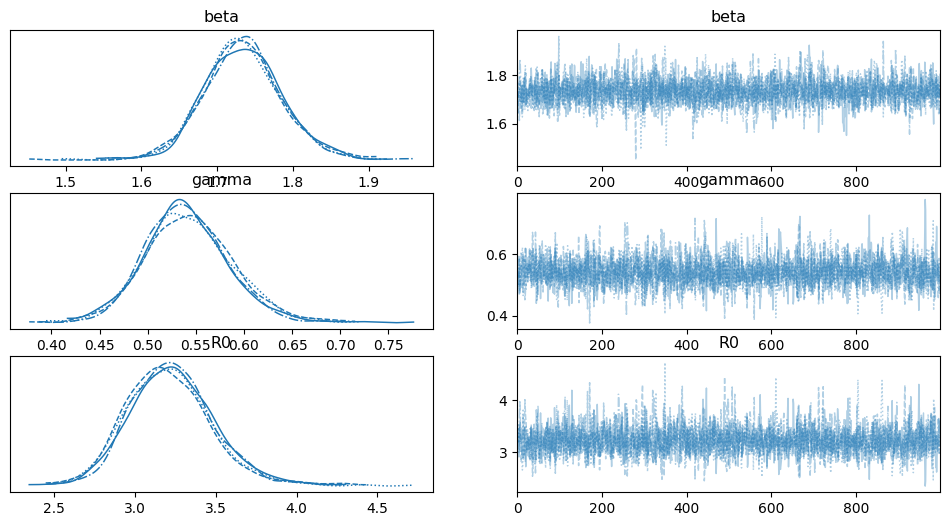

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0"]); plt.show()

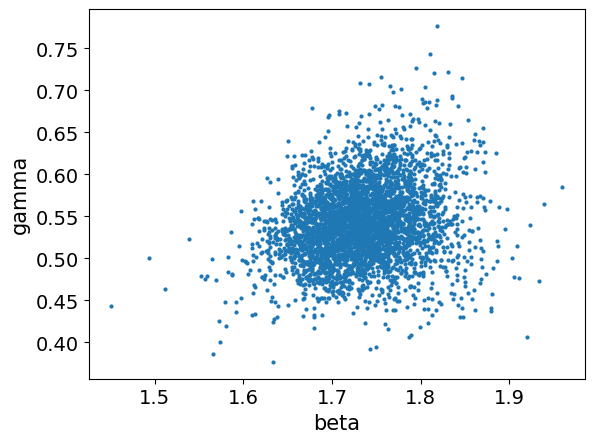

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()


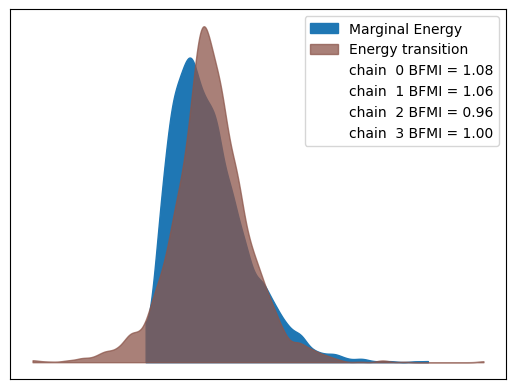

In [ ]:
az.plot_energy(idata); plt.show()

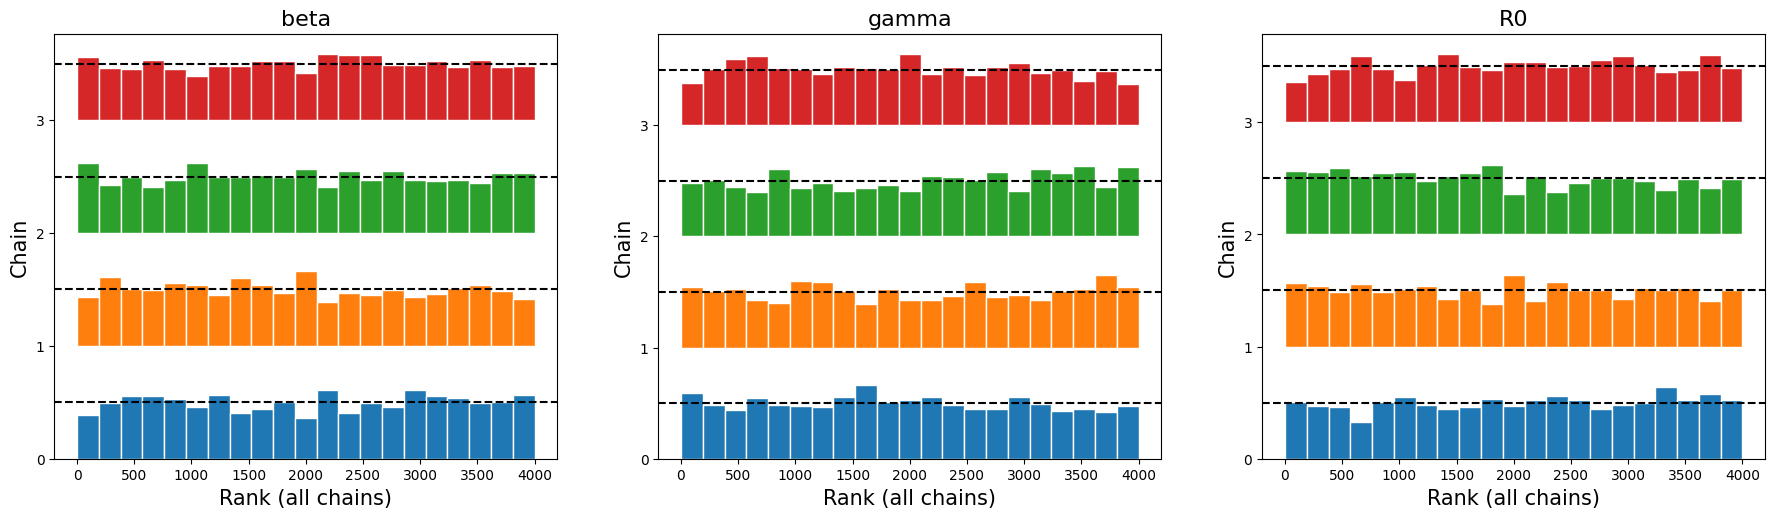

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

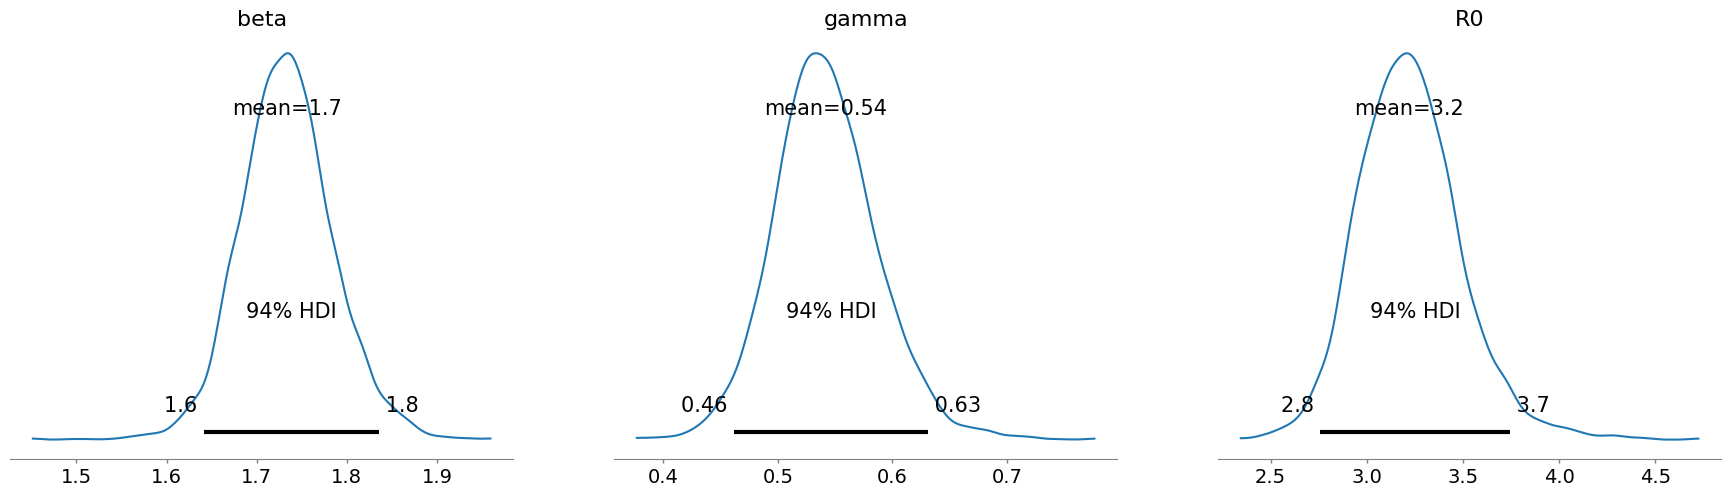

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
print(fit2.diagnose())

Processing csv files: /tmp/tmpaysutj20/sir_negbin2_log20lmraec8/sir_negbin2_log2-20251114000327_1.csv, /tmp/tmpaysutj20/sir_negbin2_log20lmraec8/sir_negbin2_log2-20251114000327_2.csv, /tmp/tmpaysutj20/sir_negbin2_log20lmraec8/sir_negbin2_log2-20251114000327_3.csv, /tmp/tmpaysutj20/sir_negbin2_log20lmraec8/sir_negbin2_log2-20251114000327_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 13 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -58.75     4.90
p_waic        1.49        -


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -58.78     4.90
p_loo        1.53        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [ ]:
df['in_bed']

,in_bed
0,3
1,8
2,26
3,76
4,225
5,298
6,258
7,233
8,189
9,128


In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

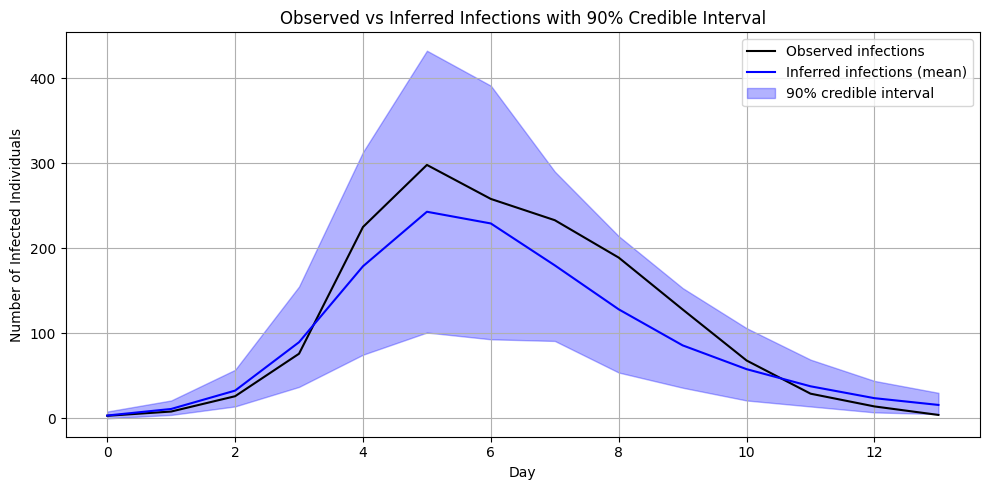

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t
# ----------------------------------------

# Thin to reduce memory load if needed
idata_thin = idata.sel(draw=slice(None, None, 10))  # Optional: use if large memory use

# Stack samples across chains and draws
I_t_samples = idata_thin.posterior["pred_cases"].stack(sample=("chain", "draw")).values  # shape: [time, samples]
#

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# If you have the original observed data in a variable like `infected`:
days = np.arange(len(I_t_mean))  # or use actual time values if available

plt.figure(figsize=(10, 5))
plt.plot(days, df["in_bed"], '-', label="Observed infections", color='black')
plt.plot(days, I_t_mean, label="Inferred infections (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Infected Individuals")
plt.title("Observed vs Inferred Infections with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('school_out.png')
plt.savefig('school_out.pdf')
plt.show()


#IEMAG Irish Pandemic Data

In [ ]:
print(os.getcwd())
print(os.listdir())

os.chdir(BASE)

# Verify
print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'sample_data']
/content/drive/MyDrive/pandemic
['data', '.ipynb_checkpoints', 'stan', 'colab-cmdstan-2.23.0.tar.gz', 'cmdstan-2.23.0', 'output', 'school_out.png', 'school_out.pdf']


In [ ]:
# --- Paths ---
#os.chdir
csv_path = (os.path.join(BASE,'data','case_data_IRL_20201111.csv'))

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model4 = CmdStanModel(stan_file="stan/sir_incidence3.stan",
                     compile="stan --build=make TBB=true")
fit4 = model4.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.
--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=sir_incidence3.stan --o=/content/drive/MyDrive/pandemic/stan/sir_incidence3.hpp /content/drive/MyDrive/pandemic/stan/sir_incidence3.stan
Warning in 'sir_incidence3.stan', line 46, column 8: integrate_ode_rk45 is
    deprecated and will be removed in Stan 3.0. Use ode_rk45 instead. 
    The new interface is slightly different, see:
    https://mc-stan.org/users/documentation/case-studies/convert_odes.html

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundia

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence3.stan

	Chain 1 had 461 iterations at max treedepth (46.1%)
	Chain 2 had 473 iterations at max treedepth (47.3%)
	Chain 4 had 465 iterations at max treedepth (46.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [ ]:
print(fit4.diagnose())

Processing csv files: /tmp/tmpaysutj20/sir_incidence3us_9q21d/sir_incidence3-20251114002731_1.csv, /tmp/tmpaysutj20/sir_incidence3us_9q21d/sir_incidence3-20251114002731_2.csv, /tmp/tmpaysutj20/sir_incidence3us_9q21d/sir_incidence3-20251114002731_3.csv, /tmp/tmpaysutj20/sir_incidence3us_9q21d/sir_incidence3-20251114002731_4.csv

Checking sampler transitions treedepth.
1399 of 4000 (34.98%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.00, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 0.001 effective draws per trans

In [ ]:
fit4.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-1.980860e+03,25.209800,35.722500,-2.043490e+03,-1.960490e+03,-1.958910e+03,2.00791,0.001786,30.92360
gamma,3.126050e+00,1.261700,1.802220,3.646400e-02,4.014200e+00,4.632880e+00,2.04035,0.001815,7.36380
beta,3.197950e+00,1.228810,1.755890,1.886260e-01,4.059820e+00,4.675000e+00,2.04187,0.001817,7.20926
phi_inv,5.762970e+00,0.699170,1.043010,4.680800e+00,5.328990e+00,7.796440e+00,2.22544,0.001980,3.03774
"y[1,1]",4.899994e+06,0.108410,4.848220,4.899990e+06,4.899990e+06,4.900000e+06,2000.00000,1.779280,1.55210
...,...,...,...,...,...,...,...,...,...
log_lik[249],-9.389410e+00,0.354219,0.528036,-1.041800e+01,-9.167980e+00,-8.859400e+00,2.22219,0.001977,3.03311
log_lik[250],-8.574960e+00,0.269869,0.397614,-9.345200e+00,-8.402240e+00,-8.193620e+00,2.17079,0.001931,3.42445
log_lik[251],-9.706190e+00,0.392611,0.591098,-1.085930e+01,-9.470550e+00,-9.090110e+00,2.26670,0.002017,2.79364
log_lik[252],-8.234480e+00,0.241301,0.354777,-8.918060e+00,-8.078550e+00,-7.895730e+00,2.16168,0.001923,3.51756


In [ ]:
idata = az.from_cmdstanpy(posterior=fit4)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     3.198  1.756   0.183    4.648      0.866    0.489     7.234   
gamma    3.126  1.802   0.033    4.605      0.889    0.502     7.213   
R0       2.012  1.738   1.008    5.170      0.864    0.501     7.213   
phi_inv  5.763  1.043   4.527    7.799      0.489    0.272     7.249   

         ess_tail  r_hat  
beta       32.220  1.533  
gamma      32.073  1.533  
R0         30.238  1.533  
phi_inv    32.795  1.535  


In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit4)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (10): 1399
Mean BFMI: 1.039863715430648
Mean step_size: 0.13701104999998281
Mean acceptance_rate: 0.9248985622500021


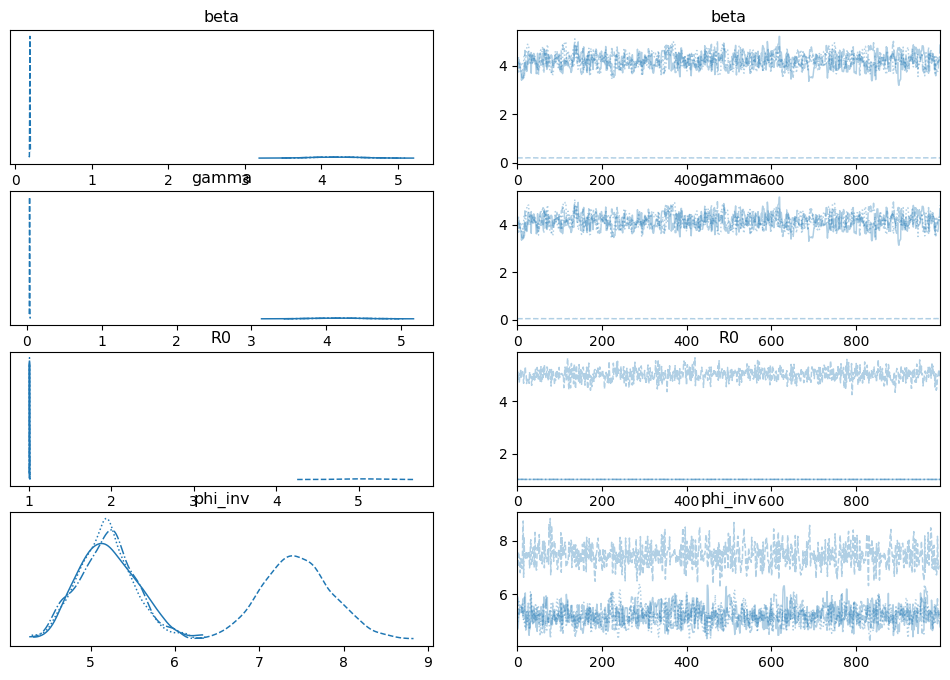

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

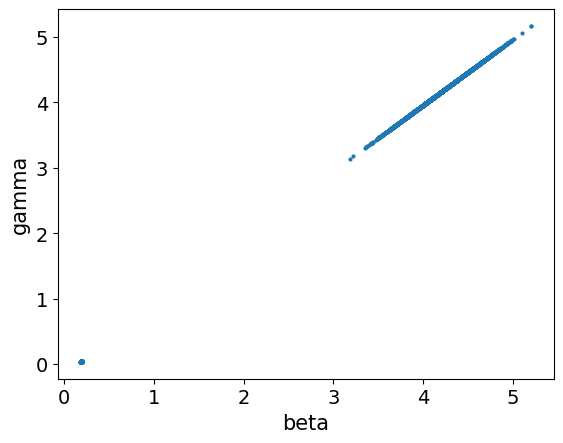

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

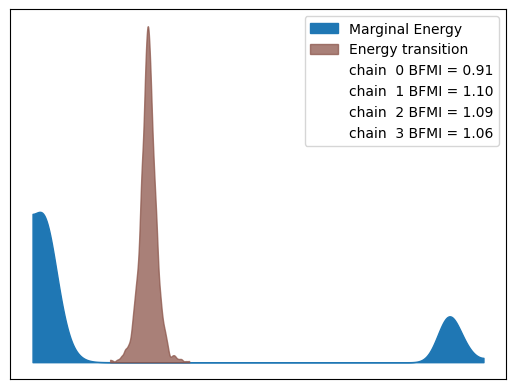

In [ ]:
az.plot_energy(idata); plt.show()

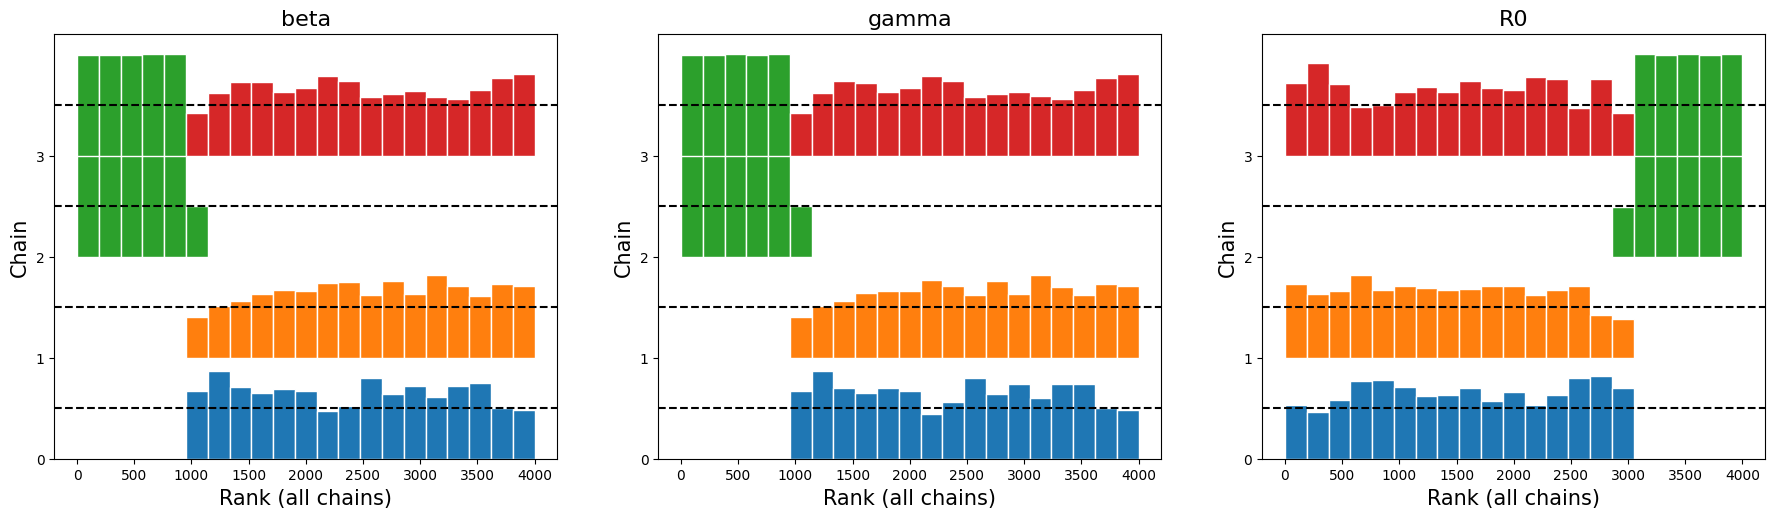

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

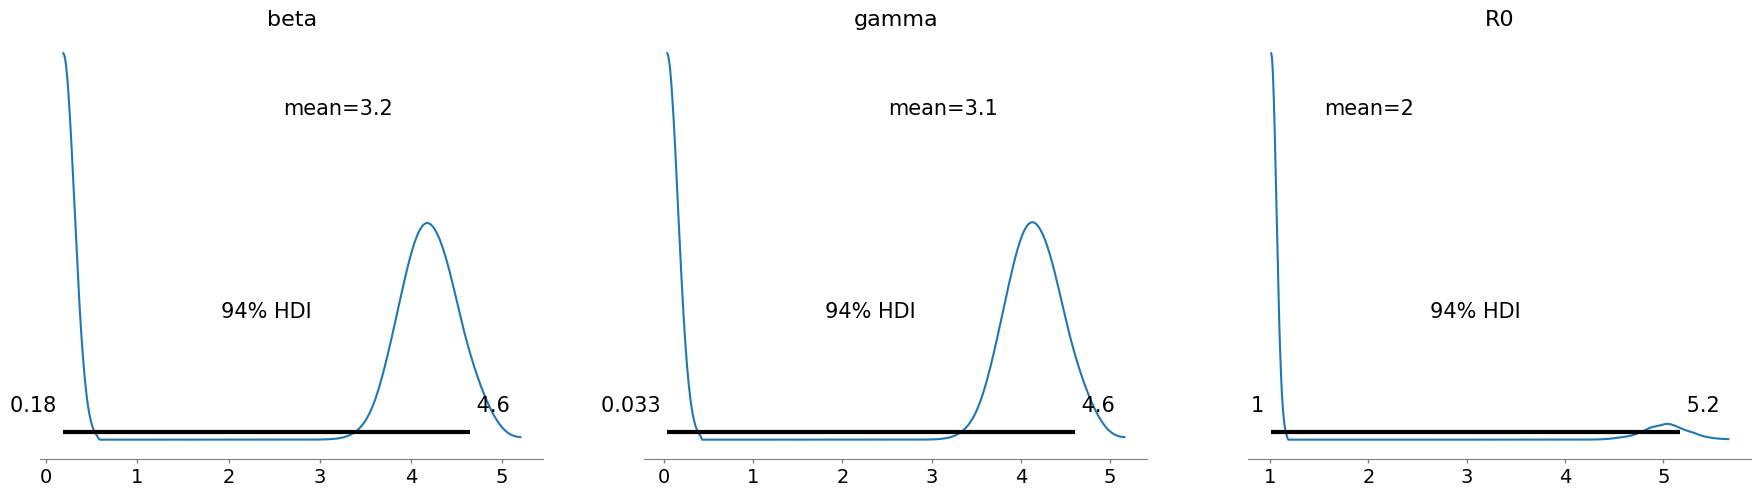

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1967.17    38.43
p_waic       66.52        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1962.64    38.00
p_loo       61.99        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



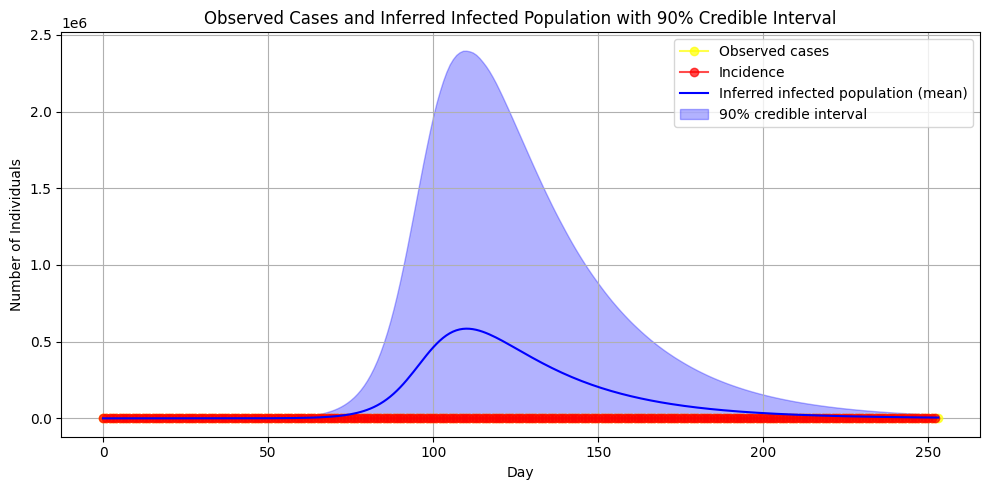

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

# Stack samples across chains and draws for the Infected compartment (second column of y)
# The shape of y in Stan is (n_days, 3) for (S, I, R)
# In ArviZ idata, y will typically have dimensions (chain, draw, y_dim_0, y_dim_1)
# where y_dim_0 corresponds to n_days and y_dim_1 corresponds to the compartments (S, I, R)
# We want the Infected compartment, which is y_dim_1 index 1.
# We then stack chain and draw dimensions to get (sample, n_days) or (n_days, sample) depending on stacking order
# Let's stack to get (n_days, sample) for easier calculation along axis=1
I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]


# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='yellow', alpha=0.7)
plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag4.png')
plt.savefig('iemag4.pdf')
plt.show()

In [ ]:
# as below, with tree depth increased to 20
# very high rhat don't look good
	Mean	MCSE	StdDev	5%	50%	95%	N_Eff	N_Eff/s	R_hat
lp__	-1.990300e+03	28.118600	39.84050	-2.031720e+03	-1.958860e+03	-1.949260e+03	2.00752	0.001756	34.48230
gamma	2.139090e+00	1.484880	2.11170	3.564630e-02	3.373980e+00	4.611210e+00	2.02247	0.001769	10.69290
beta	2.240260e+00	1.446250	2.05713	1.908440e-01	3.426350e+00	4.654580e+00	2.02320	0.001769	10.46710
phi_inv	6.077930e+00	0.773399	1.14757	4.563950e+00	6.020890e+00	7.694200e+00	2.20166	0.001925	3.20287
y[1,1]

IndentationError: unexpected indent (ipython-input-2818832432.py, line 3)

In [ ]:
# with lower nonzero bound on phi inv and uniform distribution

In [ ]:
index	Mean	MCSE	StdDev	5%	50%	95%	N_Eff	N_Eff/s	R_hat
lp__	-1950.49	0.0405791	1.2223	-1952.95	-1950.18	-1949.12	907.3	0.423439	1.00404
gamma	4.24313	0.0145886	0.30902	3.75723	4.22564	4.77674	448.691	0.209405	1.01903
beta	4.28953	0.0145114	0.307548	3.80667	4.2719	4.8206	449.167	0.209627	1.01902
phi_inv	4.97812	0.0116236	0.326373	4.43764	4.97099	5.51717	788.403	0.367949	1.01259
y[1,1]	5899991.0	0.105436	2.88355	5899990.0	5899990.0	5900000.0	747.96	0.349074	1.0064

SyntaxError: invalid syntax (ipython-input-4294671269.py, line 1)

## Irish data with tighter priors

In [ ]:

# Replace the prior lines with tighter priors
#stan_code = stan_code.replace("beta ~ normal(2, 1);", "beta ~ normal(2, 0.5);")
#stan_code = stan_code.replace("gamma ~ normal(0.4, 0.5);", "gamma ~ normal(0.4, 0.2);")
#stan_code = stan_code.replace("phi_inv ~ exponential(5);", "phi_inv ~ exponential(10);")


In [ ]:
# --- Paths ---
#os.chdir
csv_path = Path("data/case_data_IRL_20201111.csv")
#csv_path = Path("case_data_IRL_shorter.csv")

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model5 = CmdStanModel(stan_file="stan/sir_incidence4.stan",
                     compile="stan --build=make TBB=true")
fit5 = model5.sample(data=stan_data, seed=123,adapt_delta=0.95, max_treedepth=12, iter_warmup=1500)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence4.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[2] is inf, but must be finite! (in 'sir_incidence4.stan

In [ ]:
print(fit5.diagnose())

Processing csv files: /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_1.csv, /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_2.csv, /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_3.csv, /tmp/tmpiv9oclkl/sir_incidence42245e5is/sir_incidence4-20251111210651_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.02, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 0.001 effective draws per transition:
  gamma, beta, phi_inv, y[16,1], y[19,1], y[20,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[36,1], y[37,1], y[38,1], y[

In [ ]:
print(fit5.summary())
fit5.summary().to_csv("fit5_summary.csv", index=True)

                      Mean       MCSE     StdDev            5%           50%  \
lp__         -2.059520e+03  10.001800  14.208800 -2.084840e+03 -2.051550e+03   
gamma         1.608150e+00   0.641072   0.913977  3.670950e-02  2.071080e+00   
beta          1.689920e+00   0.612127   0.873153  1.891770e-01  2.129230e+00   
phi_inv       5.936120e+00   0.310434   0.545457  5.199480e+00  5.834250e+00   
y[1,1]        4.900000e+06        NaN   0.000000  4.900000e+06  4.900000e+06   
...                    ...        ...        ...           ...           ...   
log_lik[249] -9.616300e+00   0.317632   0.490609 -1.056390e+01 -9.438710e+00   
log_lik[250] -8.747090e+00   0.223026   0.342490 -9.405150e+00 -8.621940e+00   
log_lik[251] -1.000270e+01   0.346031   0.547155 -1.105250e+01 -9.824080e+00   
log_lik[252] -8.401920e+00   0.186706   0.289392 -8.954140e+00 -8.301690e+00   
log_lik[253] -8.473940e+00   0.189883   0.297651 -9.037020e+00 -8.374600e+00   

                       95%    N_Eff   N

In [ ]:
idata = az.from_cmdstanpy(posterior=fit5)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     1.690  0.873   0.184    2.386      0.431    0.245     7.350   
gamma    1.608  0.914   0.034    2.330      0.452    0.256     7.329   
R0       2.021  1.725   1.021    5.155      0.857    0.497     7.282   
phi_inv  5.936  0.545   5.131    7.072      0.213    0.093     7.924   

         ess_tail  r_hat  
beta       33.162  1.537  
gamma      29.675  1.537  
R0         29.107  1.537  
phi_inv    28.394  1.453  


In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit5)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (10): 714
Mean BFMI: 1.0426875495045518
Mean step_size: 0.1116899275000054
Mean acceptance_rate: 0.9573238799999995


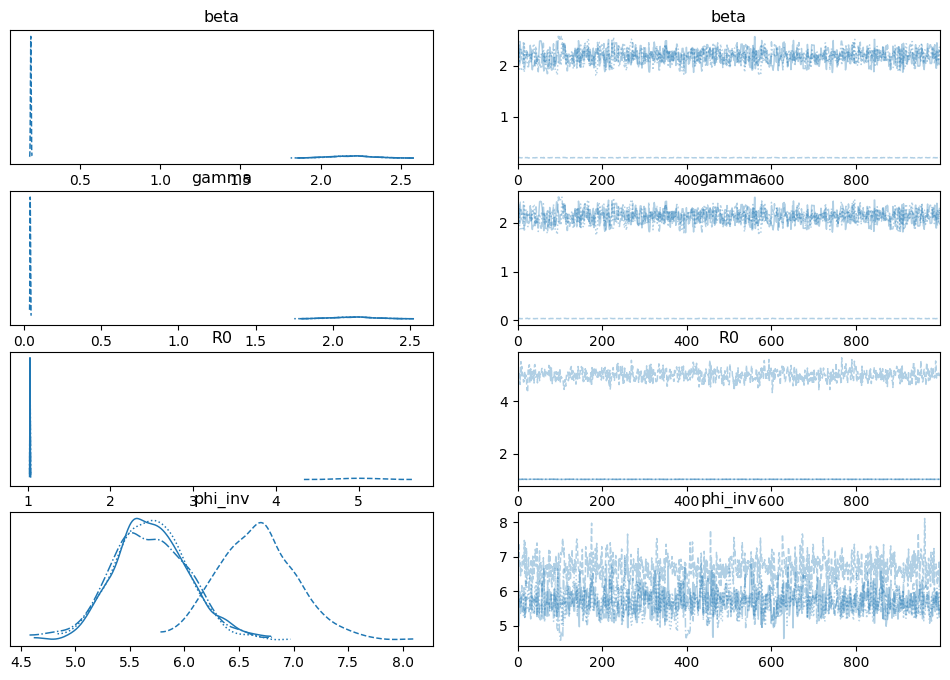

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

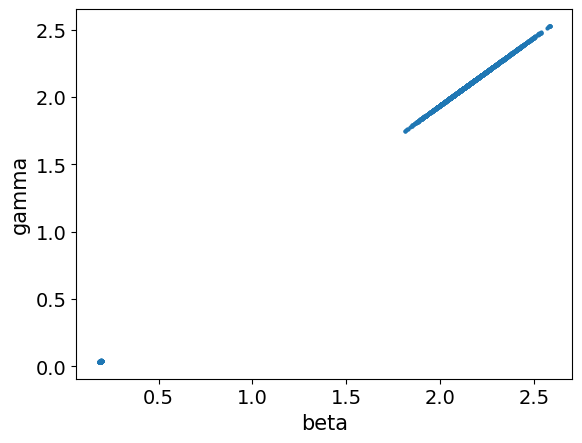

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

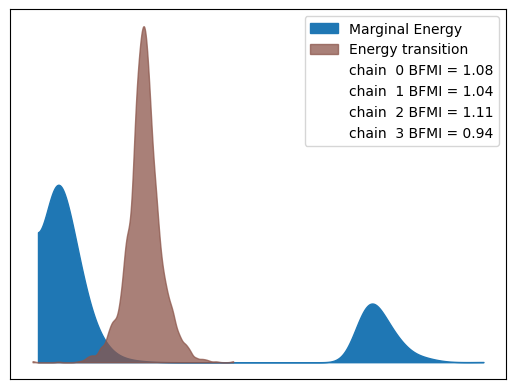

In [ ]:
az.plot_energy(idata); plt.show()

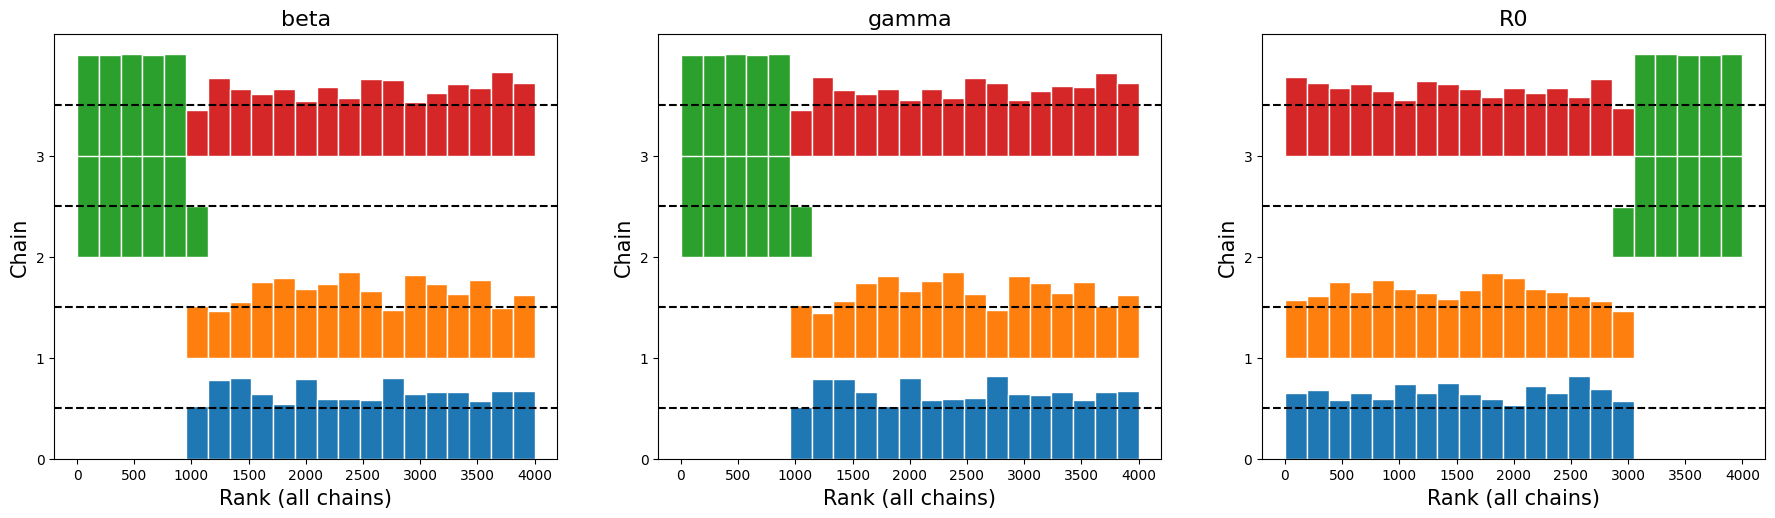

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

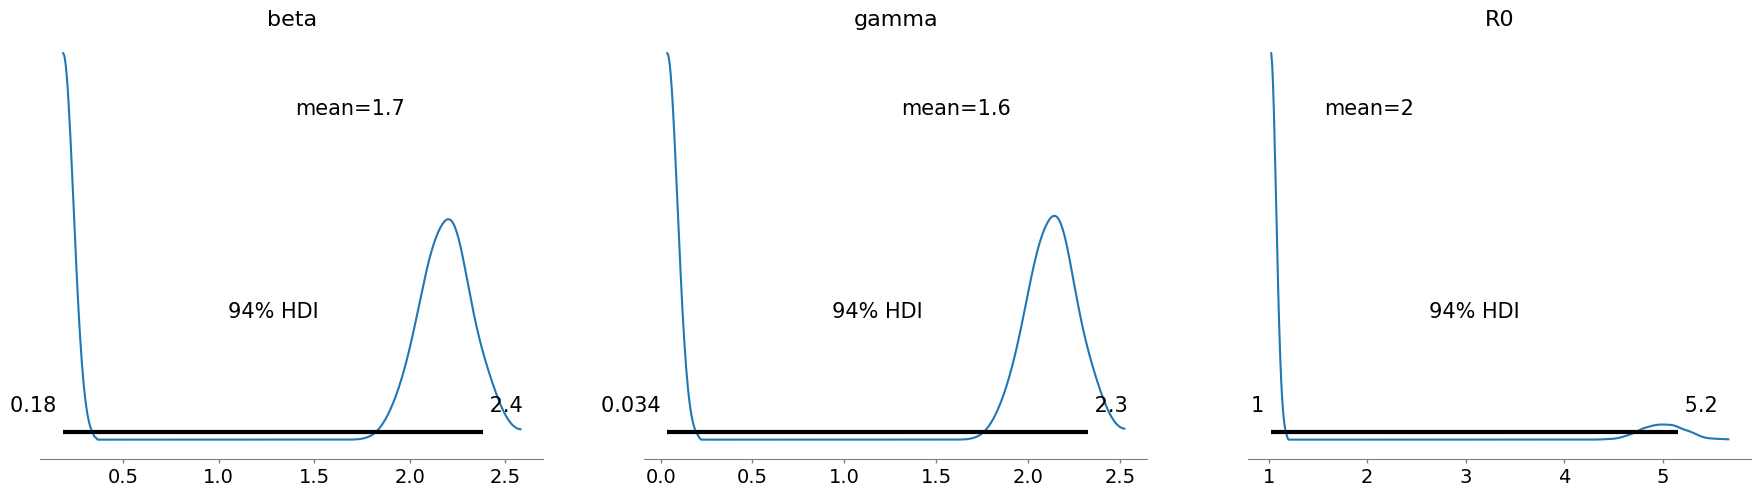

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -2007.16    41.23
p_waic       69.45        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2001.36    40.51
p_loo       63.65        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



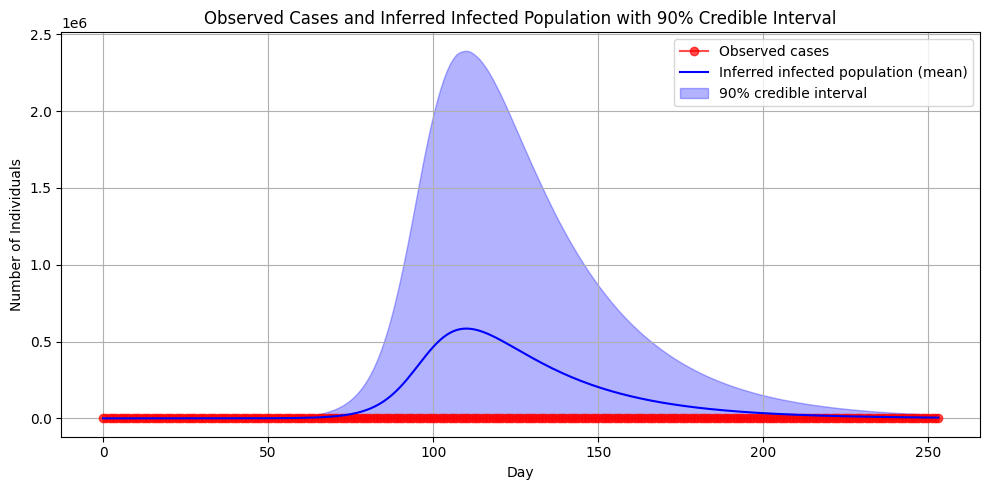

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='yellow', alpha=0.7) # Use df["daycount"] which has length n_days

plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)


# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

## Add underreporting of infections

In [ ]:
# --- Paths ---
#os.chdir
csv_path = Path("data/case_data_IRL_20201111.csv")

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model6 = CmdStanModel(stan_file="stan/sir_underreporting.stan",
                     compile="stan --build=make TBB=true")
fit6 = model6.sample(data=stan_data, seed=123,adapt_delta=0.95, max_treedepth=12, iter_warmup=1500)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2500 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -9.97934e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[55] is -1.02489e-09, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[12] is -3.15851e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[4] is -6.1061e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[56] is -1.25558e-08, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[131] is -1.07283e-09, but must be positive finite! (in 'sir_underreporting.stan', line 58, column 2 to column 55)
	Exception: n

In [ ]:
print(fit6.diagnose())

Processing csv files: /tmp/tmpiv9oclkl/sir_underreportingoz066pcj/sir_underreporting-20251111222716_1.csv, /tmp/tmpiv9oclkl/sir_underreportingoz066pcj/sir_underreporting-20251111222716_2.csv, /tmp/tmpiv9oclkl/sir_underreportingoz066pcj/sir_underreporting-20251111222716_3.csv, /tmp/tmpiv9oclkl/sir_underreportingoz066pcj/sir_underreporting-20251111222716_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.00, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following parameters had fewer than 0.001 effective draws per transition:
  gamma, beta, phi_inv, y[16,1], y[20,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[34,1

In [ ]:
fit6.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-2033.520000,25.213000,35.732000,-2056.510000,-2053.330000,-1970.590000,2.00846,0.003676,27.01820
gamma,1.063430,1.254650,1.781790,0.035324,0.039014,4.384280,2.01680,0.003691,13.26890
beta,1.189230,1.221750,1.735270,0.187108,0.192005,4.427200,2.01728,0.003692,12.98610
phi_inv,6.929520,0.702629,1.058900,4.964340,7.304350,8.140660,2.27120,0.004157,2.78100
p_reported,0.988829,0.000141,0.007573,0.974435,0.990332,0.997834,2904.32000,5.315490,1.00135
...,...,...,...,...,...,...,...,...,...
log_lik[249],-9.980420,0.356778,0.536439,-10.587100,-10.167700,-8.959010,2.26072,0.004138,2.81673
log_lik[250],-9.026620,0.271422,0.402638,-9.458990,-9.176670,-8.260890,2.20059,0.004028,3.17540
log_lik[251],-10.360200,0.395466,0.600207,-11.053400,-10.560100,-9.210750,2.30348,0.004216,2.63400
log_lik[252],-8.638810,0.242501,0.358477,-9.018790,-8.776170,-7.957190,2.18522,0.003999,3.29707


In [ ]:
idata = az.from_cmdstanpy(posterior=fit6)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     3.278  1.800   0.187    4.728      0.888    0.502     7.345   
gamma    3.204  1.847   0.032    4.684      0.911    0.515     7.306   
R0       2.033  1.775   1.008    5.271      0.882    0.512     7.288   
phi_inv  5.515  1.007   4.324    7.539      0.473    0.268     7.287   

         ess_tail  r_hat  
beta       30.359  1.532  
gamma      30.658  1.532  
R0         31.516  1.532  
phi_inv    28.902  1.532  


In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit6)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 0
Hits at max tree depth (11): 583
Mean BFMI: 1.1003587877099337
Mean step_size: 0.12831926750000391
Mean acceptance_rate: 0.9481760587499988


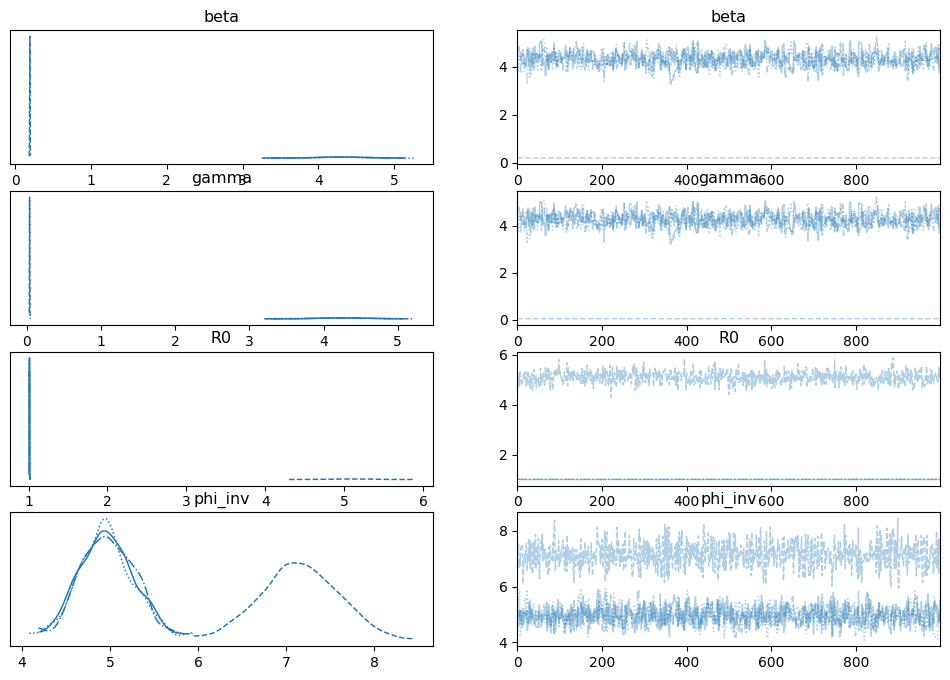

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

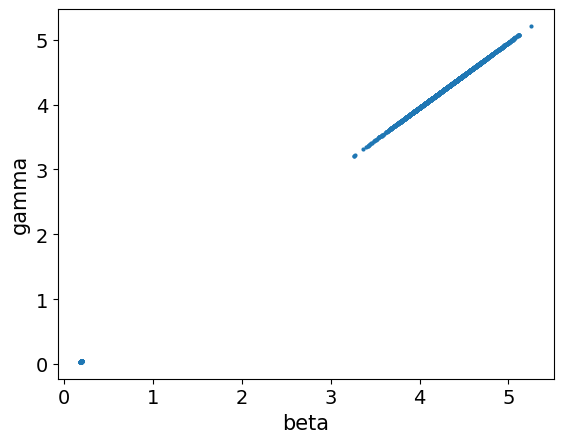

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

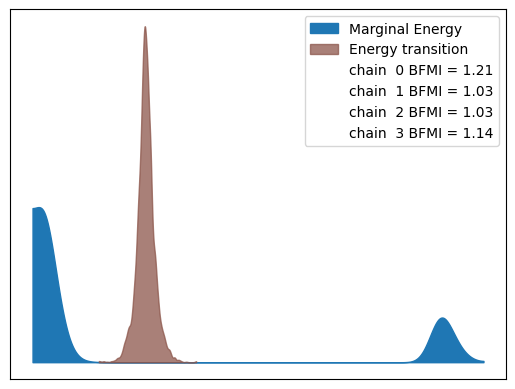

In [ ]:
az.plot_energy(idata); plt.show()

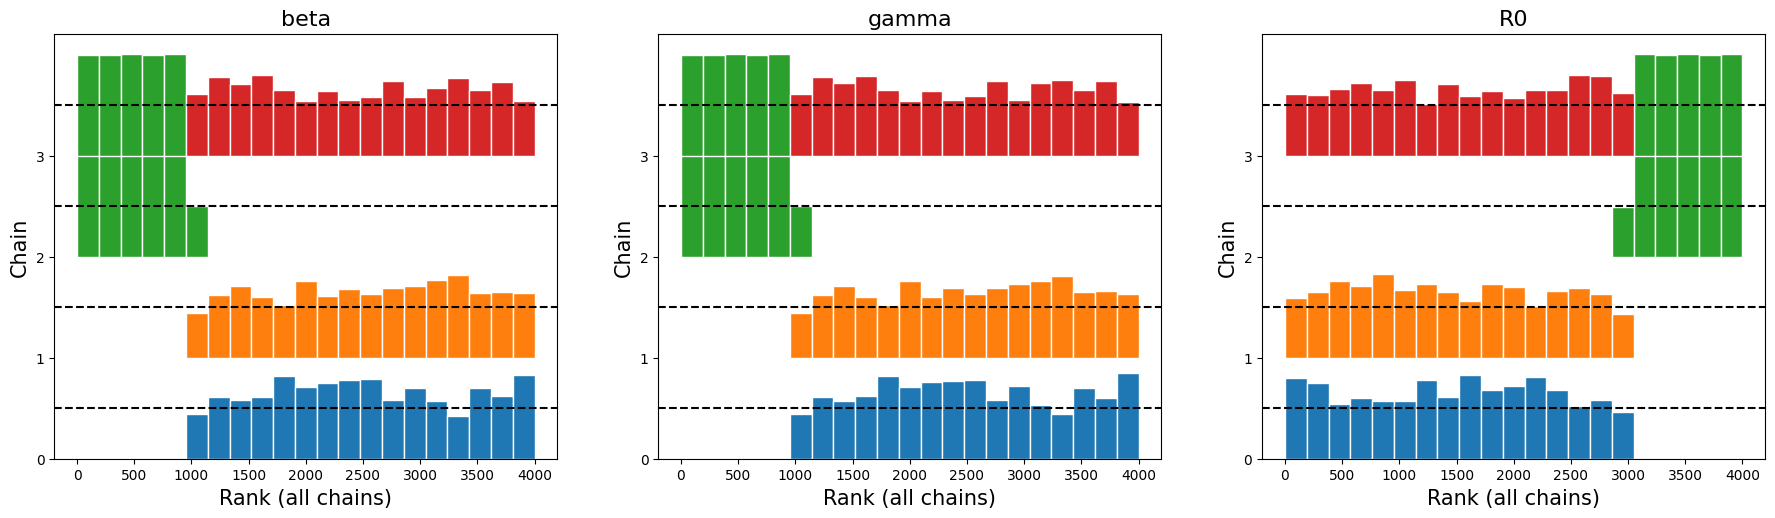

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

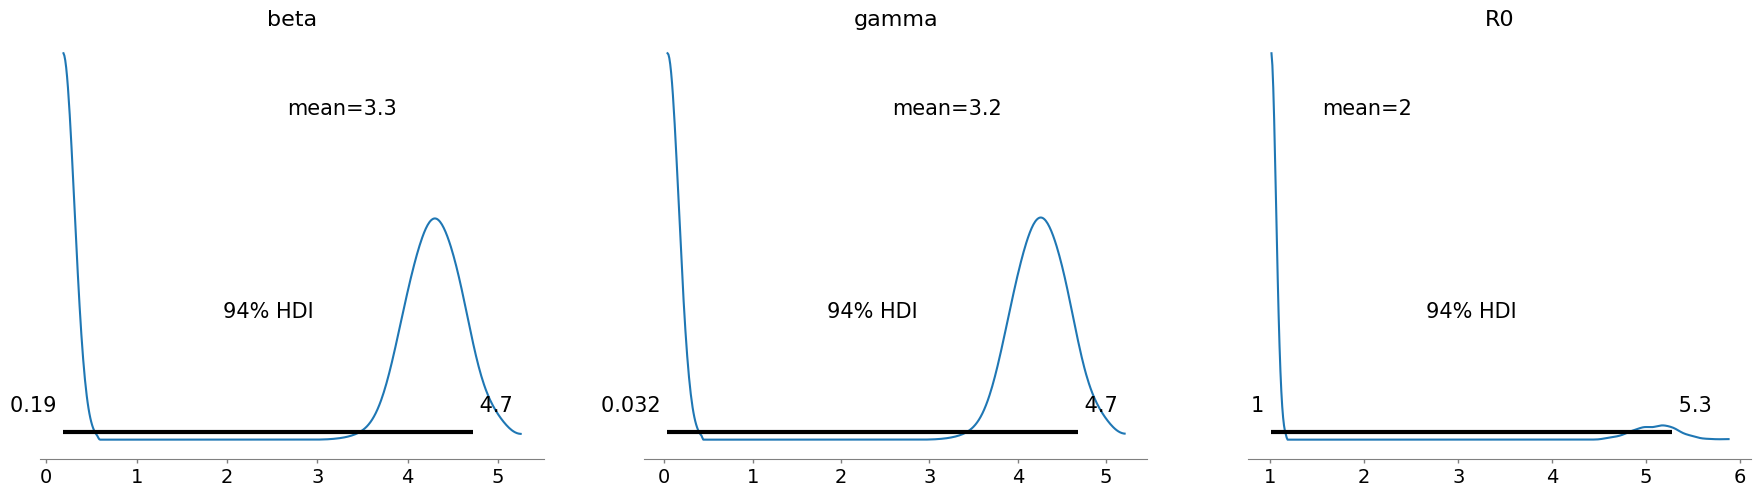

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1955.14    37.25
p_waic       64.12        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 253 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1951.10    36.87
p_loo       60.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      253  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='red', alpha=0.7) # Use df["daycount"] which has length n_days

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

NameError: name 'idata' is not defined

## Irish data - First 3 months only

In [ ]:
# --- Paths ---
csv_path = Path("case_data_IRL_shorter.csv")
stan_path = Path("sir_incidence3.stan")

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model7 = CmdStanModel(stan_file="sir_incidence3.stan",
                     compile="stan --build=make TBB=true")
fit7 = model7.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence3.stan', line 46, column 4 to column 61)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_incidence3.stan', line 60, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_inc

	Chain 1 had 107 divergent transitions (10.7%)
	Chain 2 had 12 divergent transitions (1.2%)
	Chain 3 had 300 divergent transitions (30.0%)
	Chain 4 had 260 divergent transitions (26.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [ ]:
print(fit7.diagnose())

Processing csv files: /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_1.csv, /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_2.csv, /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_3.csv, /tmp/tmpf0t5715p/sir_incidence3ypt37wyu/sir_incidence3-20251111021216_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
680 of 4000 (17.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

The following parameters had split R-hat greater than 1.05:
  gamma, beta, phi_inv, y[5,1], y[6,1], y[7,1], y[8,1], y[9,1], y[10,1], y[11,1], y[1

In [ ]:
fit7.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-4.280120e+02,0.258413,1.810330,-4.320260e+02,-4.274960e+02,-4.262730e+02,49.0779,0.299943,1.07411
gamma,1.973930e+00,0.092071,0.561790,1.064720e+00,2.020920e+00,2.682660e+00,37.2310,0.227540,1.09690
beta,2.331770e+00,0.073832,0.469745,1.534670e+00,2.379530e+00,2.934800e+00,40.4792,0.247391,1.08685
phi_inv,2.216390e+00,0.060857,0.327832,1.703630e+00,2.198850e+00,2.818900e+00,29.0187,0.177350,1.07274
"y[1,1]",4.900000e+06,NaN,0.353377,4.900000e+06,4.900000e+06,4.900000e+06,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
log_lik[48],-8.231150e+00,0.106134,0.779685,-9.403500e+00,-7.765190e+00,-7.436470e+00,53.9673,0.329825,1.08859
log_lik[49],-8.143560e+00,0.111016,0.811167,-9.353450e+00,-7.637350e+00,-7.333480e+00,53.3885,0.326288,1.09011
log_lik[50],-8.135290e+00,0.110599,0.807118,-9.340710e+00,-7.628730e+00,-7.333720e+00,53.2567,0.325482,1.09098
log_lik[51],-8.242980e+00,0.106295,0.755070,-9.360170e+00,-7.846900e+00,-7.429830e+00,50.4604,0.308392,1.08812


In [ ]:
idata = az.from_cmdstanpy(posterior=fit6)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     2.332  0.470   1.527    3.147      0.074    0.109    56.276   
gamma    1.974  0.562   1.068    2.942      0.092    0.140    51.545   
R0       1.352  0.888   1.057    1.399      0.218    0.557    47.992   
phi_inv  2.216  0.328   1.615    2.836      0.046    0.014    40.672   

         ess_tail  r_hat  
beta       18.198  1.082  
gamma      18.451  1.081  
R0         18.195  1.079  
phi_inv   128.764  1.086  


In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit7)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 680
Hits at max tree depth (9): 3
Mean BFMI: 0.8219099032327535
Mean step_size: 0.015401255000000611
Mean acceptance_rate: 0.7265241549190125


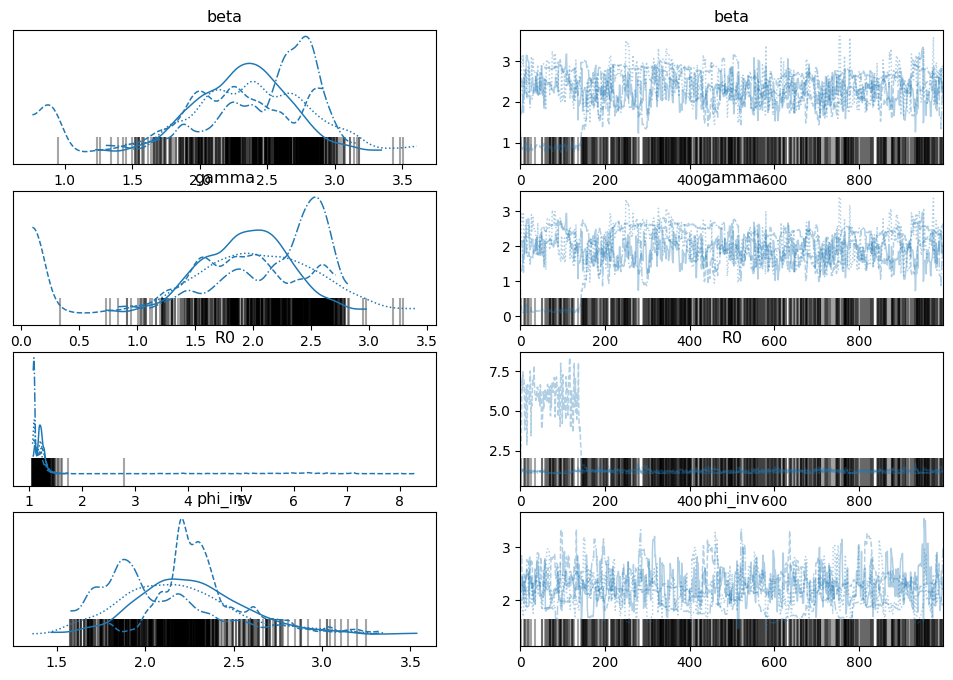

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

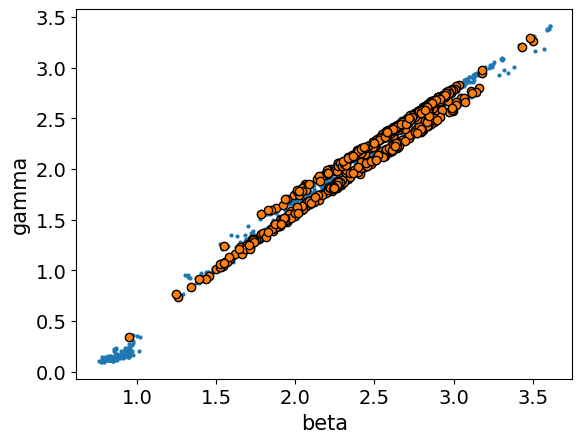

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

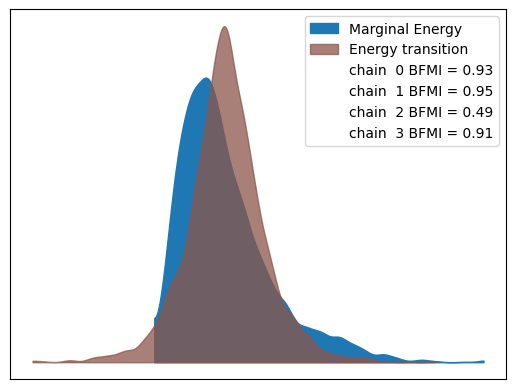

In [ ]:
az.plot_energy(idata); plt.show()

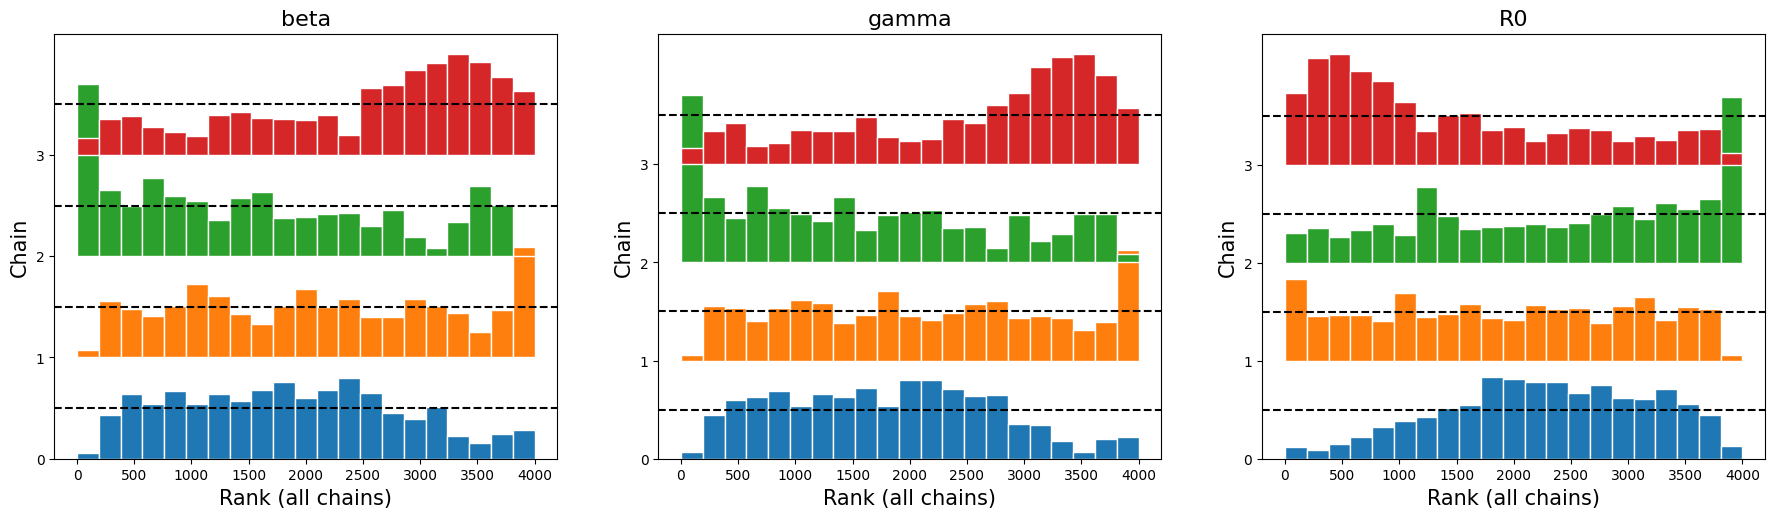

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

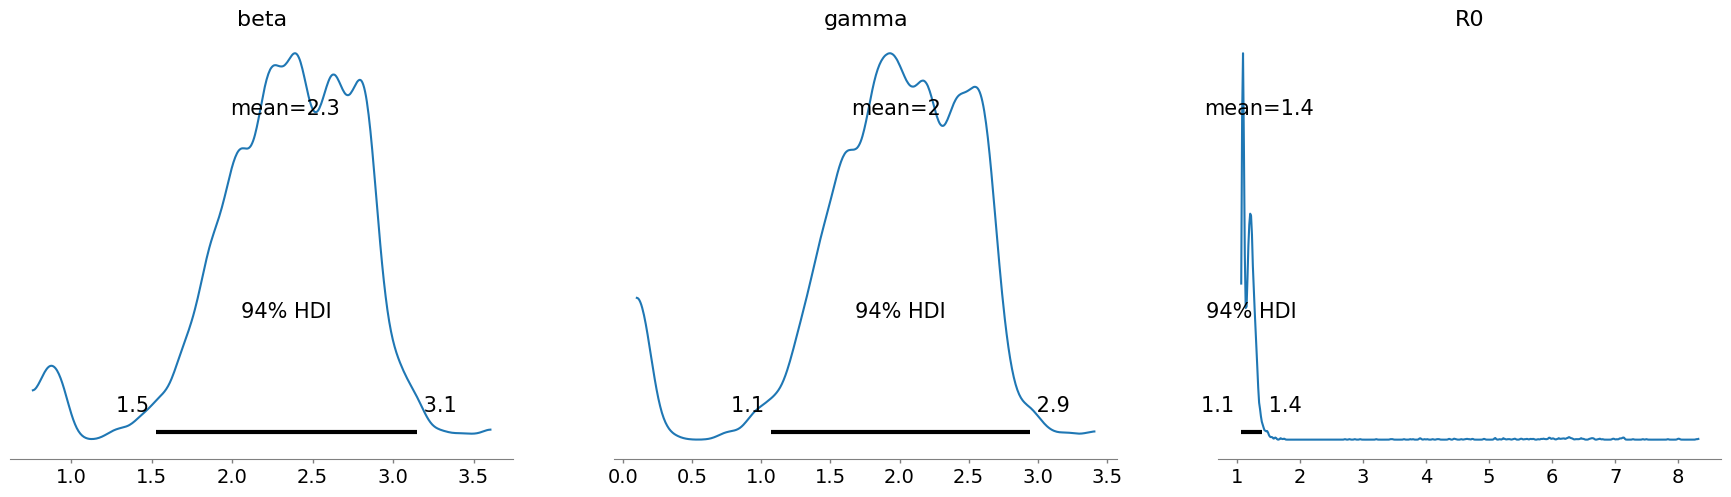

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 13 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -58.75     4.90
p_waic        1.49        -


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -422.37    10.21
p_loo       17.58        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       44   84.6%
   (0.70, 1]   (bad)         4    7.7%
   (1, Inf)   (very bad)    4    7.7%



/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


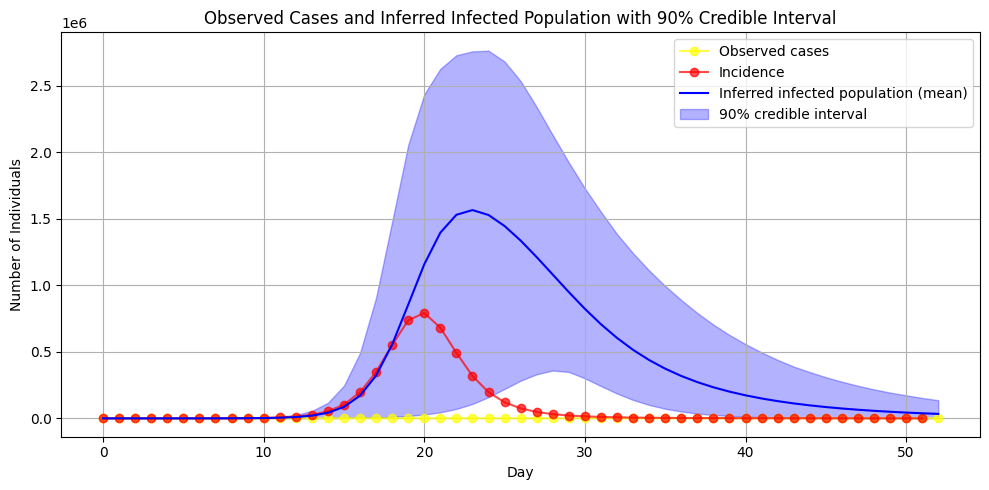

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='yellow', alpha=0.7) # Use df["daycount"] which has length n_days

plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

## Irish data - First 3 months only, tighter priors

---



In [ ]:
# --- Paths ---
csv_path = os.path.join(BASE,'data',"case_data_IRL_shorter.csv")

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model8 = CmdStanModel(stan_file=os.path.join(BASE,'stan','sir_incidence4.stan'),
                     compile="stan --build=make TBB=true")
fit8 = model8.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.
--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=sir_incidence4.stan --o=/content/drive/MyDrive/pandemic/stan/sir_incidence4.hpp /content/drive/MyDrive/pandemic/stan/sir_incidence4.stan
Warning in 'sir_incidence4.stan', line 46, column 8: integrate_ode_rk45 is
    deprecated and will be removed in Stan 3.0. Use ode_rk45 instead. 
    The new interface is slightly different, see:
    https://mc-stan.org/users/documentation/case-studies/convert_odes.html

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundia

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[9] is -2.54251e-07, but must be positive finite! (in 'sir_incidence4.stan', line 60, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: integrate_ode_rk45: ode parameters and data[1] is inf, but must be finite! (in 'sir_incidence4.stan', line 46, column 4 to column 61)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_incidence4.stan', line 60, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -nan, but must be positive finite! (in 'sir_inc

In [ ]:
print(fit8.diagnose())

Processing csv files: /tmp/tmpqso_s63h/sir_incidence4xllsk8ll/sir_incidence4-20251113005940_1.csv, /tmp/tmpqso_s63h/sir_incidence4xllsk8ll/sir_incidence4-20251113005940_2.csv, /tmp/tmpqso_s63h/sir_incidence4xllsk8ll/sir_incidence4-20251113005940_3.csv, /tmp/tmpqso_s63h/sir_incidence4xllsk8ll/sir_incidence4-20251113005940_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
693 of 4000 (17.32%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

The following parameters had split R-hat greater than 1.05:
  gamma, beta, phi_inv, y[6,1], y[7,1], y[8,1], y[9,1], y[10,1], y[11,1], y[20,1], y[

In [ ]:
fit8.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-4.473550e+02,0.082221,1.259320,-4.496920e+02,-4.470990e+02,-4.457370e+02,234.5900,5.21392,1.013680
gamma,3.716420e-01,0.041488,0.278703,1.172090e-01,2.017180e-01,8.587210e-01,45.1280,1.00300,1.083540
beta,1.026340e+00,0.026832,0.183243,8.185610e-01,9.500630e-01,1.354610e+00,46.6401,1.03661,1.078900
phi_inv,2.149790e+00,0.027535,0.248434,1.727180e+00,2.150820e+00,2.548960e+00,81.4037,1.80925,1.050900
"y[1,1]",4.900000e+06,NaN,0.000000,4.900000e+06,4.900000e+06,4.900000e+06,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
log_lik[48],-7.544940e+00,0.009712,0.126920,-7.778670e+00,-7.529250e+00,-7.365310e+00,170.7930,3.79599,1.023920
log_lik[49],-7.487390e+00,0.011376,0.145400,-7.763880e+00,-7.463180e+00,-7.283430e+00,163.3510,3.63058,1.022980
log_lik[50],-7.561920e+00,0.011713,0.198265,-7.952800e+00,-7.520820e+00,-7.303450e+00,286.5010,6.36767,1.013260
log_lik[51],-7.829050e+00,0.008057,0.314487,-8.442900e+00,-7.770090e+00,-7.441820e+00,1523.4900,33.86060,1.002570


from matplotlib import pyplot as plt
_df_0['Mean'].plot(kind='hist', bins=20, title='Mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['MCSE'].plot(kind='hist', bins=20, title='MCSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['StdDev'].plot(kind='hist', bins=20, title='StdDev')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['5%'].plot(kind='hist', bins=20, title='5%')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='5%', y='50%', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['Mean'].plot(kind='line', figsize=(8, 4), title='Mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['MCSE'].plot(kind='line', figsize=(8, 4), title='MCSE')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['StdDev'].plot(kind='line', figsize=(8, 4), title='StdDev')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['5%'].plot(kind='line', figsize=(8, 4), title='5%')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
idata = az.from_cmdstanpy(posterior=fit8)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     1.026  0.183   0.764    1.355      0.029    0.014    54.105   
gamma    0.372  0.279   0.093    0.853      0.046    0.020    51.107   
R0       4.162  2.037   1.489    7.042      0.323    0.047    50.693   
phi_inv  2.150  0.248   1.688    2.564      0.030    0.015    69.271   

         ess_tail  r_hat  
beta       46.496  1.058  
gamma      48.702  1.060  
R0         61.339  1.060  
phi_inv    94.781  1.051  


In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit8)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 693
Hits at max tree depth (7): 1
Mean BFMI: 1.069667787061458
Mean step_size: 0.08947042500000868
Mean acceptance_rate: 0.7436054998366419


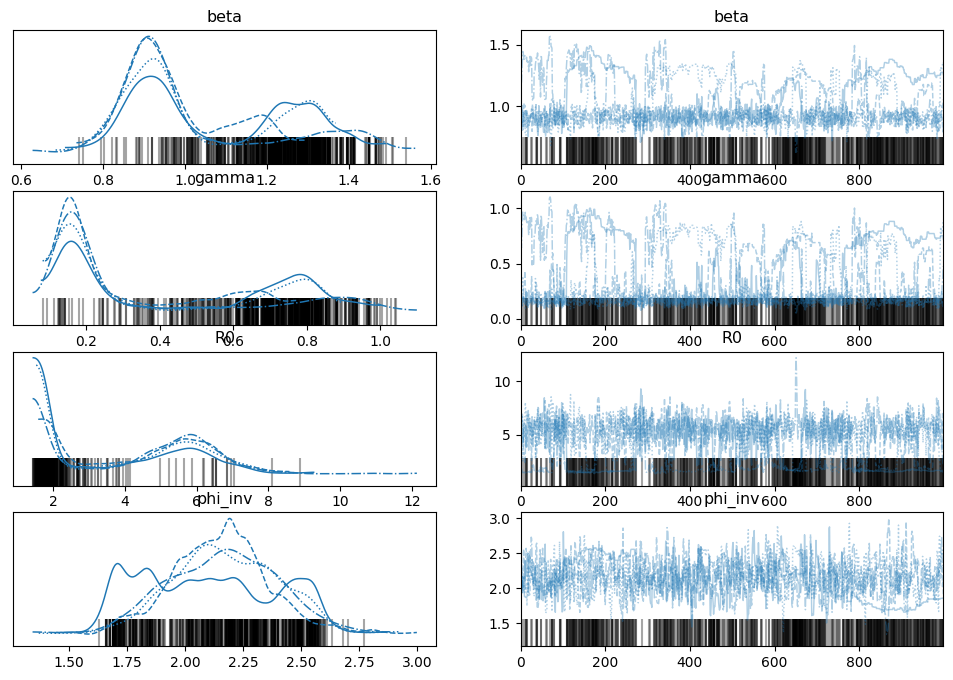

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","phi_inv"]); plt.show()

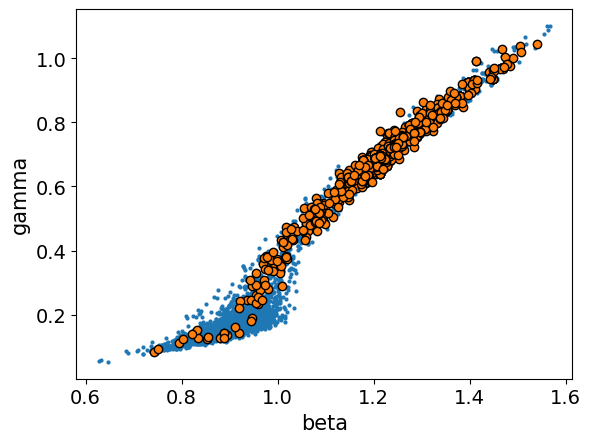

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

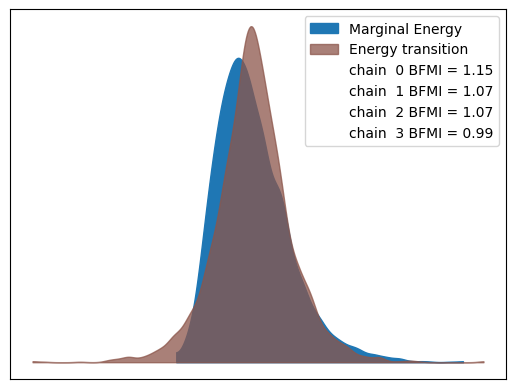

In [ ]:
az.plot_energy(idata); plt.show()

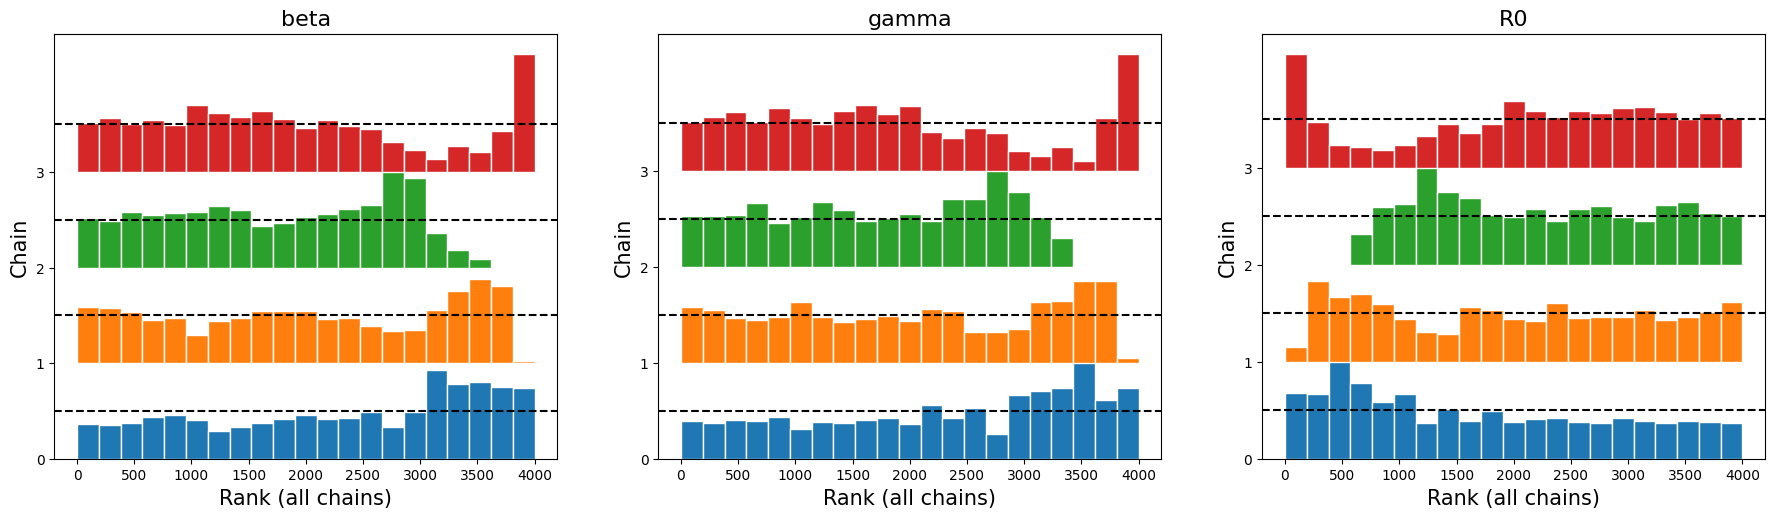

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

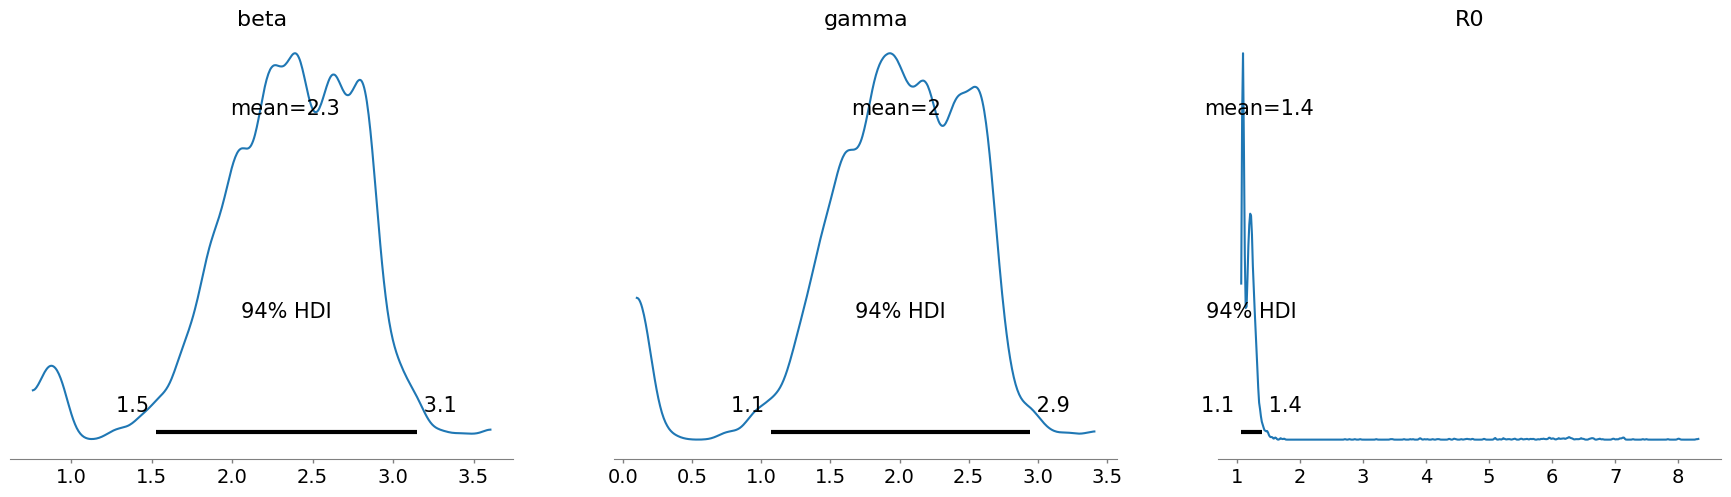

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -428.08    11.97
p_waic       10.83        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -427.75    11.93
p_loo       10.50        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       52  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



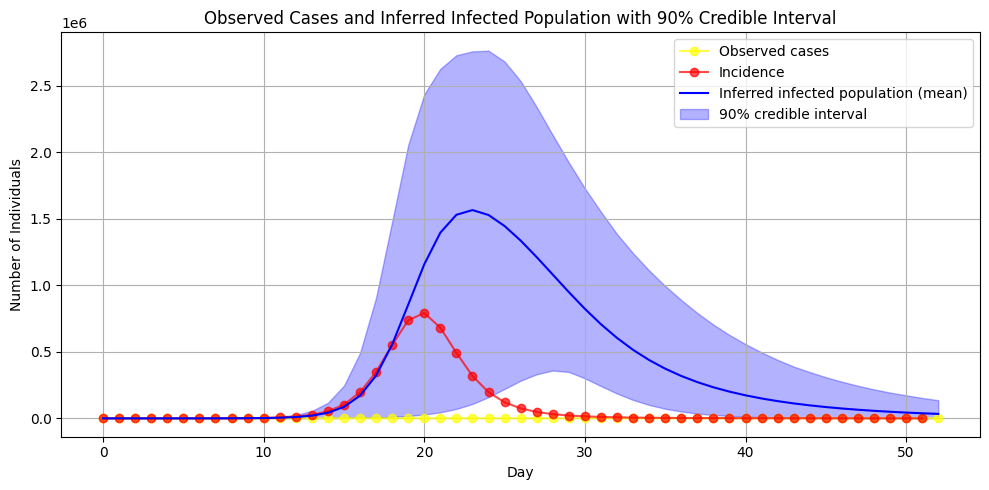

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='yellow', alpha=0.7) # Use df["daycount"] which has length n_days

plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

#plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

## SEIR model - Add Exposed

In [ ]:
# --- Paths ---
csv_path = os.path.join(BASE,'data',"case_data_IRL_shorter.csv")

In [ ]:
# --- Load data ---
df = pd.read_csv(csv_path)

In [ ]:
cases = df["daycount"].astype(int).to_numpy()
n_days = len(cases)

In [ ]:
# --- Time axis used by Stan ODE block ---
t0 = 0.0
# Typical choice: one time unit per row. Stan expects strictly increasing ts:
ts = np.arange(1, n_days + 1, dtype=float)

In [ ]:
# --- Population size (N)---
N = 4900000

In [ ]:
# Initial conditions [S0, I0, R0]; common choice starts with 1 infected, 0 recovered.
y0 = np.array([N - 1, 1, 0], dtype=float)

In [ ]:
# --- Build Stan data list (must match the Stan file's data block) ---
stan_data = {
    "n_days": int(n_days),
    "y0": y0.astype(float),
    "t0": float(t0),
    "ts": ts.astype(float),
    "N": int(N),
    "cases": cases.astype(int),
}

In [ ]:
model9 = CmdStanModel(stan_file=os.path.join(BASE,'stan','seir_incidence3.stan'),
                     compile="stan --build=make TBB=true")
fit9 = model9.sample(data=stan_data, seed=123)

If you wish to force recompilation, use force_compile=True instead.
--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=seir_incidence3.stan --o=/content/drive/MyDrive/pandemic/stan/seir_incidence3.hpp /content/drive/MyDrive/pandemic/stan/seir_incidence3.stan
Warning in 'seir_incidence3.stan', line 55, column 6: integrate_ode_rk45 is
    deprecated and will be removed in Stan 3.0. Use ode_rk45 instead. 
    The new interface is slightly different, see:
    https://mc-stan.org/users/documentation/case-studies/convert_odes.html

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/su

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: neg_binomial_2_lpmf: Location parameter[24] is -1.17225e-07, but must be positive finite! (in 'seir_incidence3.stan', line 73, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -3.7308e-08, but must be positive finite! (in 'seir_incidence3.stan', line 73, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[1] is -3.14754e-09, but must be positive finite! (in 'seir_incidence3.stan', line 73, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location parameter[5] is -4.21325e-09, but must be positive finite! (in 'seir_incidence3.stan', line 73, column 2 to column 55)
	Exception: integrate_ode_rk45: ode parameters and data[3] is inf, but must be finite! (in 'seir_incidence3.stan', line 55, column 2 to column 74)
	Exception: neg_binomial_2_lpmf: Location parameter[3] is -3.24491e-09, but must be positive finite! (in 'seir_incidence3.stan', line 73, column 2 to column 55)
	Exception: neg_binomial_2_lpmf: Location paramet

In [ ]:
print(fit9.diagnose())

Processing csv files: /tmp/tmpaysutj20/seir_incidence3kxnjlacz/seir_incidence3-20251114015623_1.csv, /tmp/tmpaysutj20/seir_incidence3kxnjlacz/seir_incidence3-20251114015623_2.csv, /tmp/tmpaysutj20/seir_incidence3kxnjlacz/seir_incidence3-20251114015623_3.csv, /tmp/tmpaysutj20/seir_incidence3kxnjlacz/seir_incidence3-20251114015623_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
908 of 4000 (22.70%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.20, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

The following pa

In [ ]:
fit9.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-402.03600,3.797250,5.934010,-412.659000,-399.76400,-396.60400,2.44207,0.003653,2.33235
gamma,1.73283,0.235628,0.440862,1.054440,1.76471,2.43427,3.50066,0.005237,1.49946
beta,2.51642,0.031804,0.348025,1.982960,2.50473,3.09057,119.74800,0.179140,1.06449
a,1.64521,0.437711,0.693632,0.562196,1.81603,2.58325,2.51121,0.003757,2.13490
phi_inv,1.26627,0.258707,0.408433,0.753824,1.13765,1.97721,2.49243,0.003729,2.20788
...,...,...,...,...,...,...,...,...,...
log_lik[48],-7.16745,0.111988,0.216319,-7.498010,-7.12600,-6.87193,3.73115,0.005582,1.44513
log_lik[49],-7.08717,0.107926,0.216397,-7.392790,-7.04406,-6.79533,4.02021,0.006014,1.39278
log_lik[50],-7.14052,0.097072,0.235773,-7.496450,-7.10705,-6.82118,5.89925,0.008825,1.22224
log_lik[51],-7.42018,0.058944,0.343181,-8.038320,-7.38233,-6.97079,33.89800,0.050711,1.03898


In [ ]:
idata = az.from_cmdstanpy(posterior=fit9)

# Summary incl. mean, sd, mcse, r_hat, ess_bulk/tail
print(az.summary(idata, var_names=["beta","gamma","R0","a","phi_inv"], round_to=3))

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta     2.516  0.348   1.884    3.185      0.053    0.013    42.699   
gamma    1.733  0.441   0.967    2.416      0.161    0.040     7.948   
R0       1.526  0.367   1.188    2.210      0.176    0.108     7.083   
a        1.645  0.694   0.434    2.541      0.304    0.132     6.797   
phi_inv  1.266  0.408   0.734    2.034      0.180    0.086     7.070   

         ess_tail  r_hat  
beta      917.793  1.065  
gamma      17.903  1.453  
R0         15.049  1.547  
a          11.328  1.586  
phi_inv    19.907  1.554  


In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [ ]:
# Convert your CmdStanPy fit to InferenceData
idata = az.from_cmdstanpy(posterior=fit9)

# See what sampler stats are present
print("sample_stats vars:", list(idata.sample_stats.data_vars))

# Divergences
div = idata.sample_stats["diverging"]
n_div = int(div.sum())
print("Divergences:", n_div)

# Tree depth (ArviZ name is 'tree_depth')
if "tree_depth" in idata.sample_stats:
    td = idata.sample_stats["tree_depth"]
    max_td = int(td.max())
    n_max_td = int((td == max_td).sum())
    print(f"Hits at max tree depth ({max_td}):", n_max_td)
else:
    print("No 'tree_depth' in sample_stats (backend/version mismatch?).")

# BFMI (energy diagnostic; <~0.3 can be concerning)
bfmi_values = az.bfmi(idata)
if np.isscalar(bfmi_values):
    print("BFMI:", float(bfmi_values))
else:
    print("Mean BFMI:", float(np.mean(bfmi_values)))

# Step size & acceptance rate
if "step_size" in idata.sample_stats:
    print("Mean step_size:", float(idata.sample_stats["step_size"].mean()))
else:
    print("No 'step_size' in sample_stats.")

# ArviZ uses 'acceptance_rate' for Stan backends
if "acceptance_rate" in idata.sample_stats:
    print("Mean acceptance_rate:", float(idata.sample_stats["acceptance_rate"].mean()))
else:
    print("No 'acceptance_rate' in sample_stats.")

sample_stats vars: ['acceptance_rate', 'diverging', 'energy', 'lp', 'n_steps', 'step_size', 'tree_depth']
Divergences: 908
Hits at max tree depth (8): 1
Mean BFMI: 0.8034446428247685
Mean step_size: 0.04534435000000239
Mean acceptance_rate: 0.6992957479393642


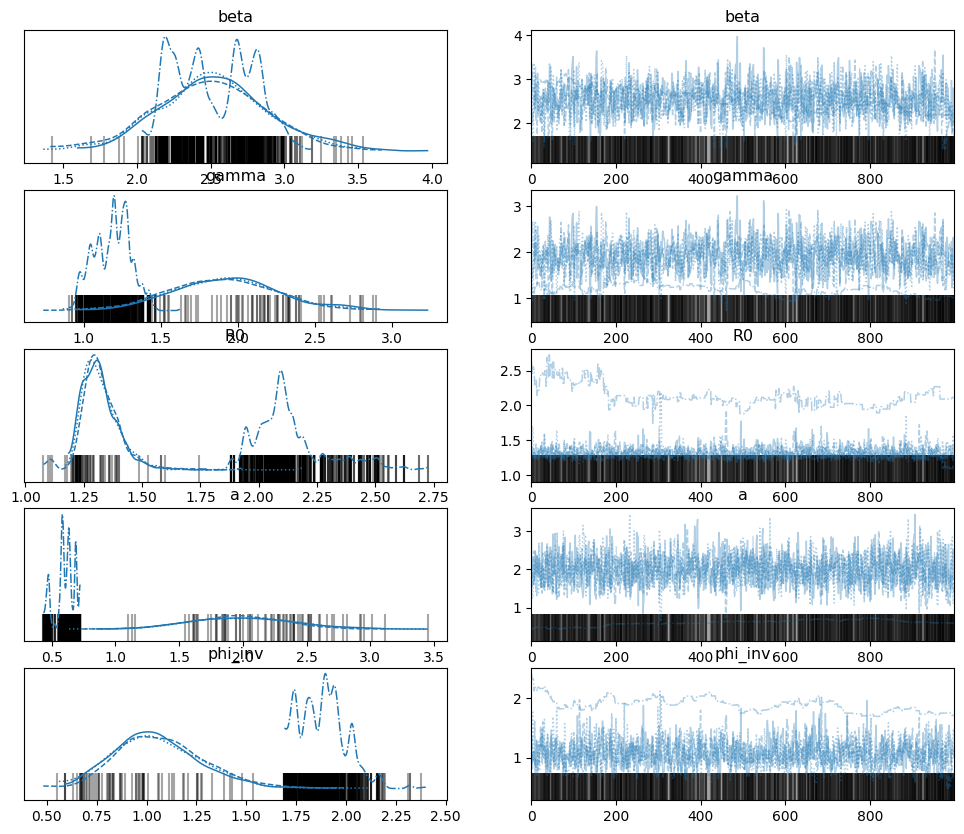

In [ ]:
az.plot_trace(idata, var_names=["beta","gamma","R0","a","phi_inv"]); plt.show()

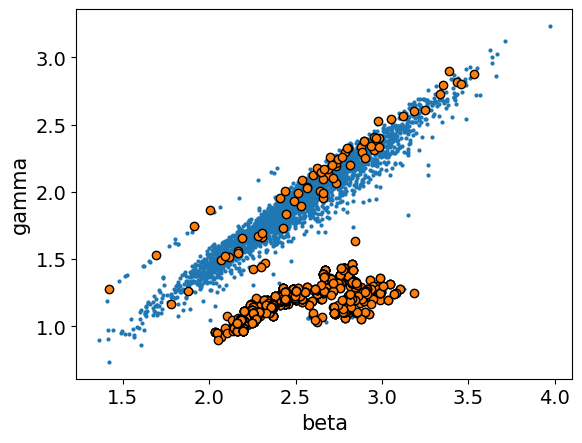

In [ ]:
az.plot_pair(idata, var_names=["beta","gamma"], kind="scatter", divergences=True); plt.show()

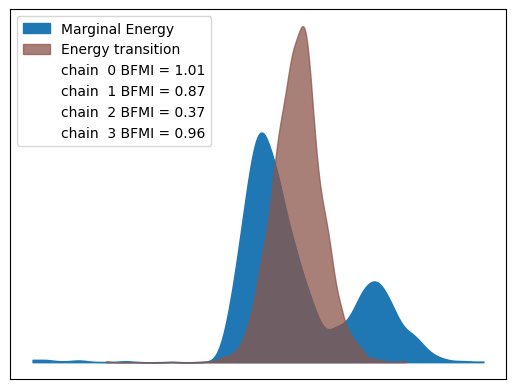

In [ ]:
az.plot_energy(idata); plt.show()

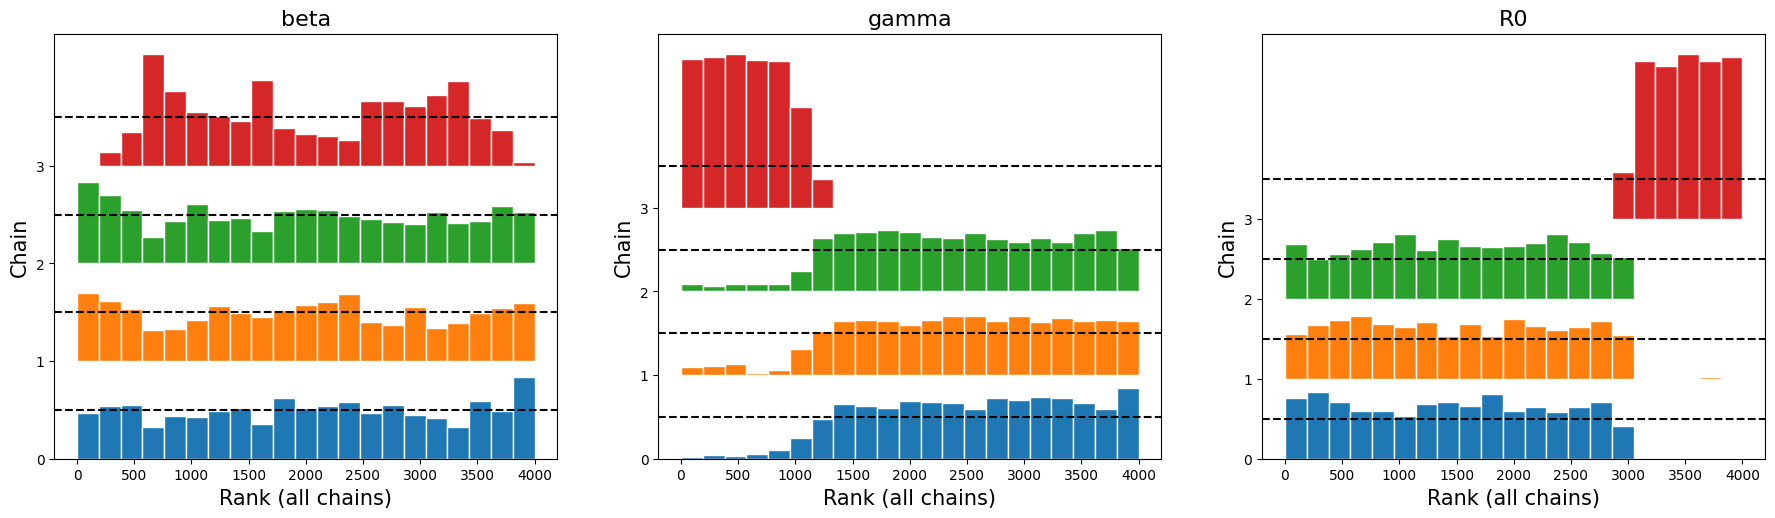

In [ ]:
az.plot_rank(idata, var_names=["beta","gamma","R0"]); plt.show()

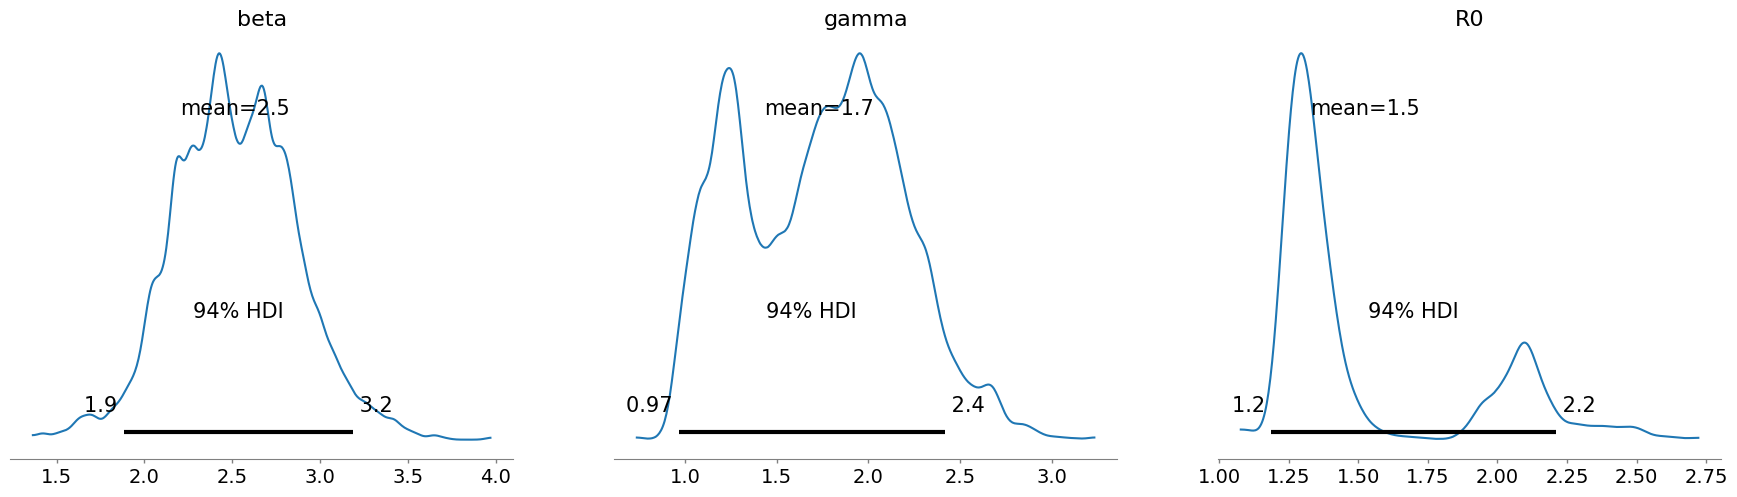

In [ ]:
az.plot_posterior(idata, var_names=["beta","gamma","R0"]); plt.show()

In [ ]:
# Calculate WAIC
waic = az.waic(idata)
print("\nWAIC:")
print(waic)



WAIC:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -387.54     9.50
p_waic        4.64        -


In [ ]:
# Calculate LOO
loo = az.loo(idata)
print("\nLOO:")
print(loo)


LOO:
Computed from 4000 posterior samples and 52 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -387.59     9.51
p_loo        4.69        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       52  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



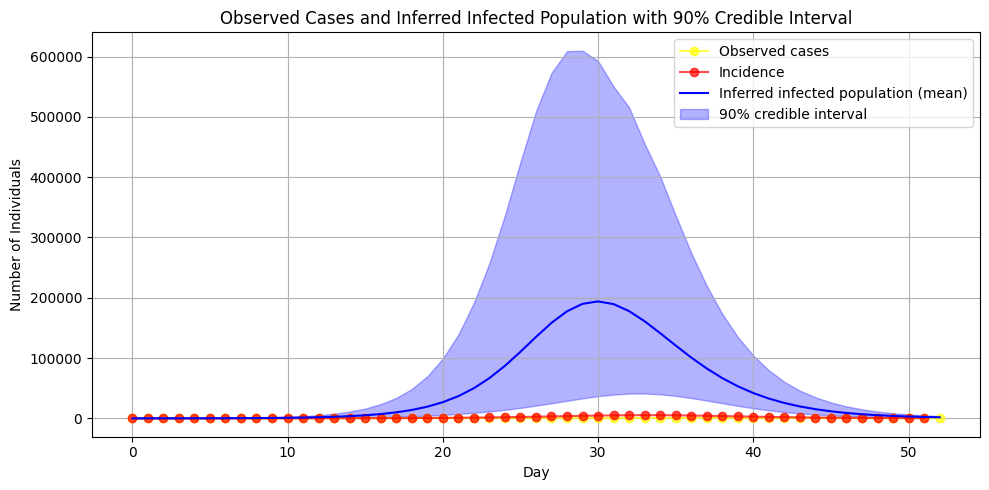

In [ ]:
# ----------------------------------------
# 1. Extract posterior samples of I_t (Infected Population)
# ----------------------------------------

# Thin to reduce memory load if needed (optional)
# idata_thin = idata.sel(draw=slice(None, None, 10))

I_t_samples = idata.posterior["y"].sel(y_dim_1=1).stack(sample=("chain", "draw")).values # shape: [n_days, samples]

# ----------------------------------------
# 2. Compute Posterior Mean and 90% HDI
# ----------------------------------------
# Now I_t_samples is a 2D numpy array (n_days, samples)
I_t_mean = np.mean(I_t_samples, axis=1)
I_t_lower = np.percentile(I_t_samples, 5, axis=1)
I_t_upper = np.percentile(I_t_samples, 95, axis=1)

# ----------------------------------------
# 3. Plot Observed vs Inferred Infections
# ----------------------------------------

# Create a time axis with length n_days
days = np.arange(len(I_t_mean)) # This will now be of length n_days

plt.figure(figsize=(10, 5))
# Plot observed cases
plt.plot(days, df["daycount"], 'o-', label="Observed cases", color='yellow', alpha=0.7) # Use df["daycount"] which has length n_days

plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

#plt.plot(days[:-1], idata.posterior['incidence'][0][0],'o-', label="Incidence", color='red', alpha=0.7)

# Plot inferred infections (mean and credible interval)
plt.plot(days, I_t_mean, label="Inferred infected population (mean)", color='blue')
plt.fill_between(days, I_t_lower, I_t_upper, color='blue', alpha=0.3, label="90% credible interval")

plt.xlabel("Day")
plt.ylabel("Number of Individuals")
plt.title("Observed Cases and Inferred Infected Population with 90% Credible Interval")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iemag5.png')
plt.savefig('iemag5.pdf')
plt.show()

##Clean the notebook file to save into Github

In [8]:
import nbformat as nbf
from pathlib import Path

path = Path("CmdStanPy2.ipynb")  # your file

nb = nbf.read(path, as_version=4)

# 1) Remove the widgets metadata entirely
nb.metadata.pop("widgets", None)


nbf.write(nb, path)
print("Cleaned and saved:", path)


FileNotFoundError: [Errno 2] No such file or directory: 'CmdStanPy2.ipynb'

In [ ]:
# Will raise if the notebook is still malformed
import nbformat, nbconvert
nb = nbformat.read("CmdStanPy1 20251111.ipynb", as_version=4)
from nbconvert.exporters import HTMLExporter

html_exporter = HTMLExporter()
html_exporter.template_name = 'classic' # You can choose a different template if you like

# Export the notebook to HTML
(body, resources) = html_exporter.from_notebook_node(nb)

# Save the HTML output to a file
with open('CmdStanPy1 20251111.html', 'w') as f:
    f.write(body)

print("Notebook exported to CmdStanPy1 20251111.html")
print("Validation OK")

Notebook exported to CmdStanPy1 20251111.html
Validation OK
